# Exercise in Data Transformation and Exploratory Data Analysis

This notebook contains the exercises for the class of February 5, 2025, in the course Data & Things at Roskilde University.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Exercise 3

Do an exploratory data analysis of the adult dataset. The cell below loads the dataset from UCI Machine Learning Repository into a pandas dataframe called `adult_data`. It requires that you have installed the package `ucimlrepo`. (Otherwise the dataset is on moodle page for this class.)

The Adult Dataset is a well-known dataset available from the UCI Machine Learning Repository. The dataset is derived from US census data and is commonly used for machine learning and data analysis tasks. The main objective of the dataset is to predict whether an individual's annual income exceeds $50K based on demographic and employment related attributes.

In [7]:
from ucimlrepo import fetch_ucirepo 
adult = fetch_ucirepo(id=2) 
X = adult.data.features 
y = adult.data.targets 
X["income"] = y
adult_data = X.copy()

adult_data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


The Adult dataset contains demographic and employment information about individuals. The goal is to predict whether a person earns more than $50K/year (income). It has ~48,000 rows and 14 columns, including numerical and categorical variables. The target variable is income.


In [8]:
# Check for missing values and data types
print(adult_data.info())

# Count the '?' values which are common in this UCI dataset
print("\nMissing values (marked as '?'):")
print((adult_data == '?').sum())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None

Missing values (marked as '?'):
age                  0
workclass         1836
fnlwgt   

Variables and Data Types:
Numerical: age, fnlwgt, education-num, capital-gain, capital-loss, hours-per-week
Categorical: workclass, education, marital-status, occupation, relationship, race, sex, native-country, income
Some categorical columns contain missing values marked as '?' (e.g., workclass, occupation).

In [10]:
# Basic stats for numerical columns (age, capital-gain, etc.)
display(adult_data.describe())

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


Descriptive Statistics (Numerical):
Most individuals are aged 25–45 years. The median hours worked per week is around 40. Capital-gain and capital-loss are mostly 0, with a few extreme values. Education-num reflects the number of years of formal education.

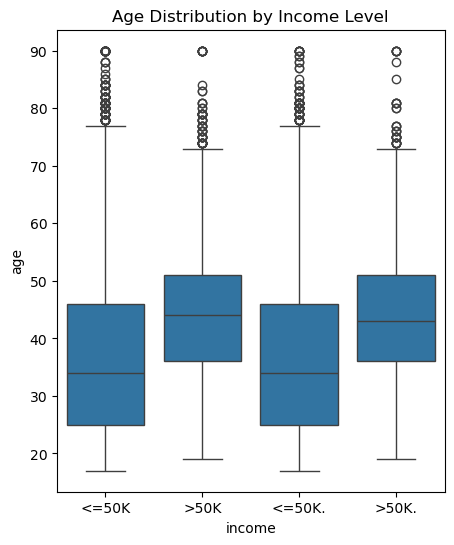

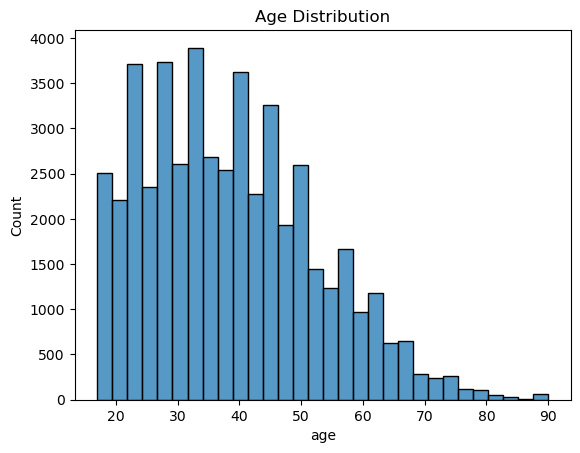

In [11]:
# Visualization 1: Income distribution by Age
plt.figure(figsize=(5, 6))
sns.boxplot(x='income', y='age', data=adult_data)
plt.title('Age Distribution by Income Level')
plt.show()
#Age Distribution
sns.histplot(adult_data['age'], bins=30)
plt.title("Age Distribution")
plt.show()

Age Analysis:
Most individuals are between 25–45 years old. Higher-income individuals tend to be slightly older, as shown by the boxplot.

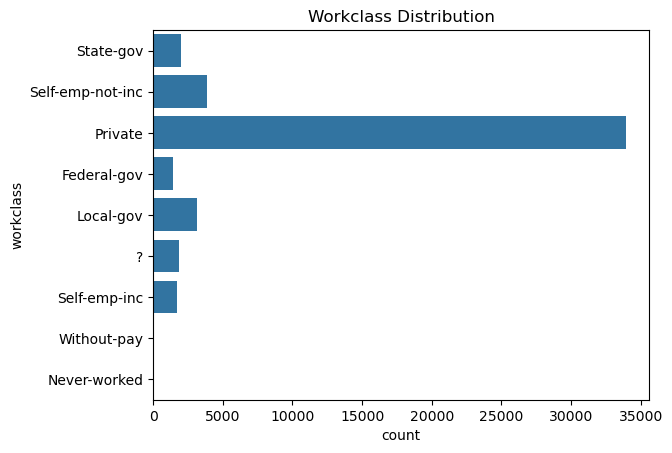

In [14]:

#Workclass Distribution
sns.countplot(y=adult_data["workclass"])
plt.title("Workclass Distribution")
plt.show()

Workclass Analysis:
The majority of individuals work in the Private sector. Other work categories like Self-emp or Government are less common.

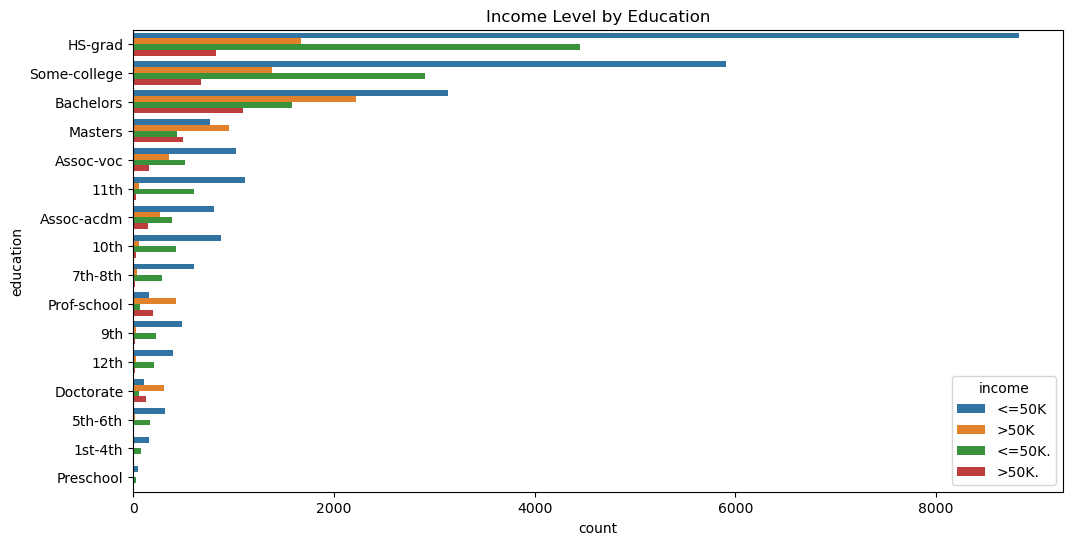

In [16]:

# Visualization 2: Education level vs Income
plt.figure(figsize=(12, 6))
sns.countplot(y='education', hue='income', data=adult_data, order=adult_data['education'].value_counts().index)
plt.title('Income Level by Education')
plt.show()

Education vs Income:
Individuals with higher education levels (e.g., Bachelors, Masters) are more likely to earn >50K.

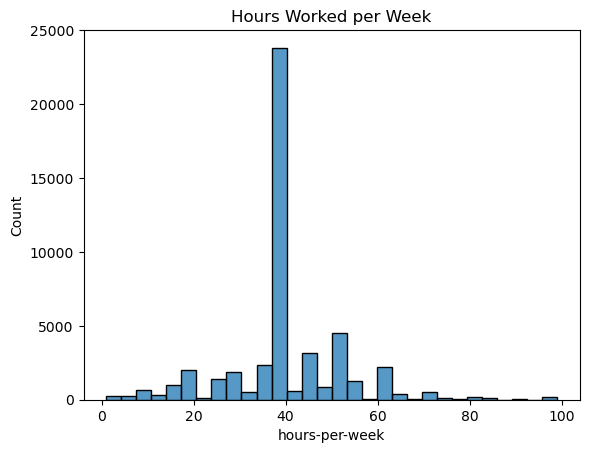

In [17]:
#Hours per Week Distribution
sns.histplot(adult_data["hours-per-week"], bins=30)
plt.title("Hours Worked per Week")
plt.show()

Hours per Week:
Most people work around 40 hours per week. There are few individuals working very low (<20) or very high (>60) hours.

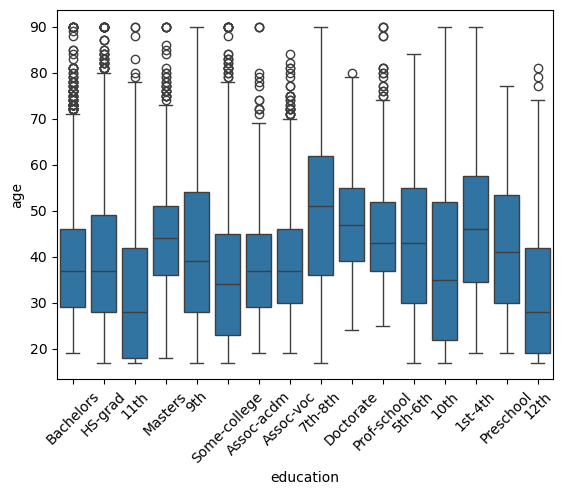

In [18]:
#Education vs Age
sns.boxplot(data=adult_data, x="education", y="age")
plt.xticks(rotation=45)
plt.show()

Education vs Age:
Higher education levels are associated with slightly older age groups, as the median age increases with education level.

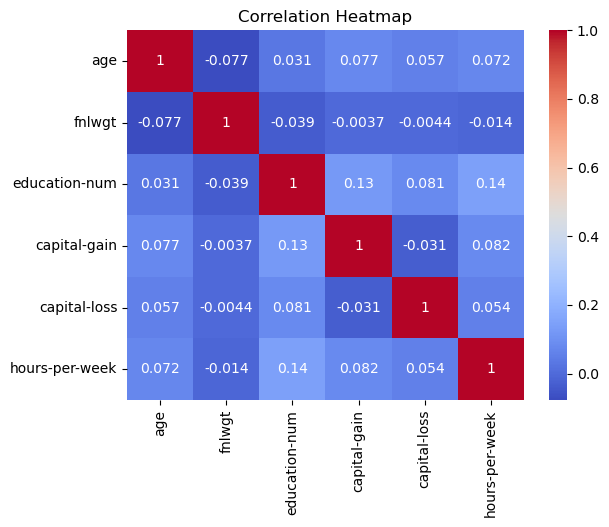

In [19]:
#Relationship Between Variables
#Numeric vs Numeric Variables
numeric = adult_data.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Numeric vs Numeric Relationships:
Age and hours-per-week have a small positive correlation. Education-num is moderately correlated with age. Most other numeric variables show weak correlations.

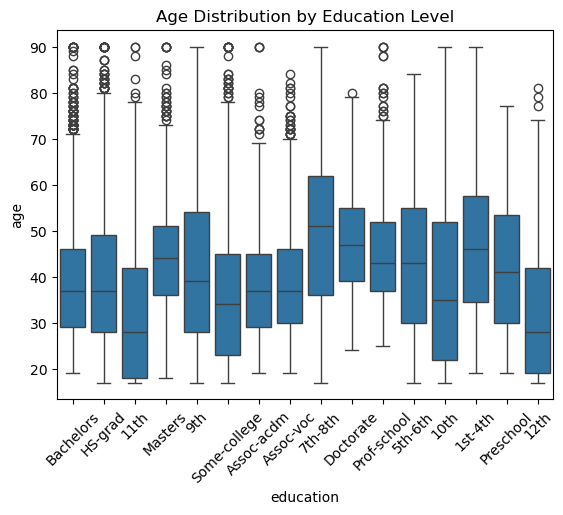

In [20]:
#Categorical vs Numeric Variables
sns.boxplot(data=adult_data, x="education", y="age")
plt.xticks(rotation=45)
plt.title("Age Distribution by Education Level")
plt.show()


Categorical vs Numeric:
The boxplot shows how age varies across education levels. People with higher education tend to be slightly older.

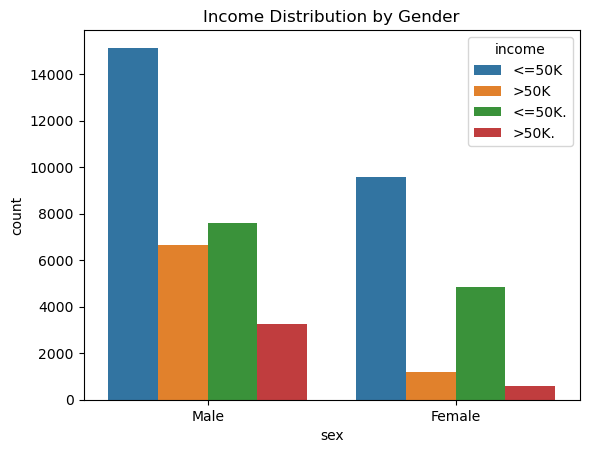

In [21]:
#Categorical vs Categorical Variables
sns.countplot(x="sex", hue="income", data=adult_data)
plt.title("Income Distribution by Gender")
plt.show()

Categorical vs Categorical:
Males are more likely to earn >50K compared to females. This shows a clear difference in income distribution by gender.

## Exercise in Statistics
## Exercise 3

Load in the data "energySoftware.csv" and answer the following questions:
1. Plot the distribution of CPU for each test type
2. Is there a difference in the CPU between bubblesort and bubblesort_ll? (note that the last name contains two small l's and not two capital i's) Justify your choice of test(s). 
3. Is there a difference in the CPU between bubblesort_func and bubblesort_ll2? Justify your choice of test(s). If there is a difference, how big is it?
4. When it comes to time, is there a difference between bubblesort and bubblesort_ll? Justify your choice of test(s).
5. Perform an ANOVA test to test if there is a difference in means across groups for time

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Load dataset
energy_data = pd.read_csv("energySoftware.csv")

# Inspect dataset
energy_data.head()

,test,PKG,CPU,nn,nn2,time
0,bubblesort,0.010986,0.009155,,,3.165
1,bubblesort,0.013184,0.010925,,,3.069
2,bubblesort,0.015198,0.009399,,,2.617
3,bubblesort,0.010559,0.009583,,,2.572
4,bubblesort,0.009949,0.009949,,,2.671


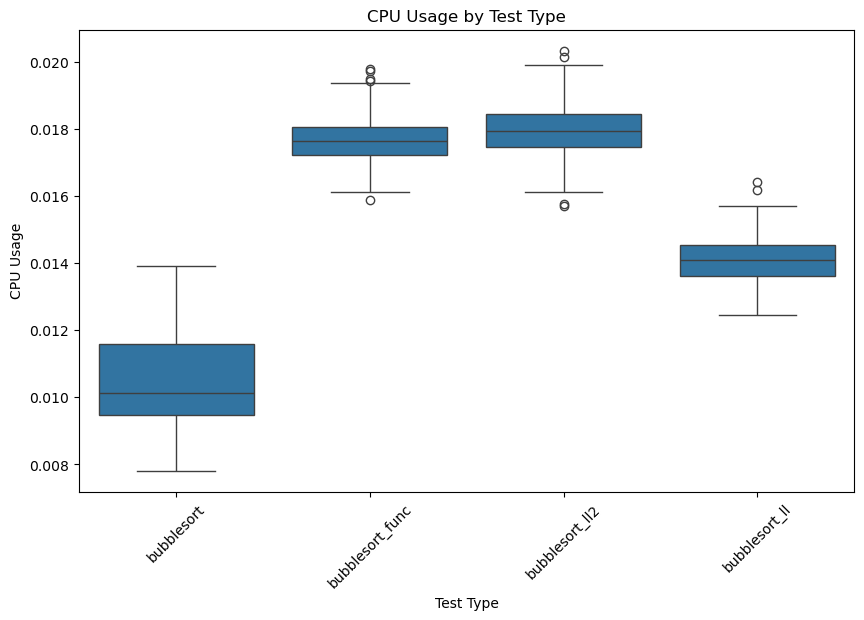

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='test', y='CPU', data=energy_data)
plt.title('CPU Usage by Test Type')
plt.xlabel('Test Type')
plt.ylabel('CPU Usage')
plt.xticks(rotation=45)
plt.show()

In [24]:
#2 bubblesort and bubblesort_ll
# Get the data
bs = energy_data[energy_data['test'] == 'bubblesort']['CPU'].dropna()
bs_ll = energy_data[energy_data['test'] == 'bubblesort_ll']['CPU'].dropna()

print(f"bubblesort: mean={bs.mean():.4f}, n={len(bs)}")
print(f"bubblesort_ll: mean={bs_ll.mean():.4f}, n={len(bs_ll)}")

# Check normality with Shapiro-Wilk test
stat_bs, p_bs = stats.shapiro(bs)
stat_ll, p_ll = stats.shapiro(bs_ll)

print(f"bubblesort normality p-value: {p_bs:.4f}")
print(f"bubblesort_ll normality p-value: {p_ll:.4f}")

# Reason for this test choice:
# If p > 0.05 for both groups, data is normal → use t-test
# If p ≤ 0.05 for either group, data is NOT normal → use Mann-Whitney

if p_bs > 0.05 and p_ll > 0.05:
    print("Both groups appear normal. Using independent t-test.")
    stat, p_value = stats.ttest_ind(bs, bs_ll, equal_var=False)
    print(f"Welch's t-test p-value: {p_value:.4f}")
else:
    print("At least one group is not normal. Using Mann-Whitney U test.")
    stat, p_value = stats.mannwhitneyu(bs, bs_ll)
    print(f"Mann-Whitney U test p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: There is a significant difference in CPU between bubblesort and bubblesort_ll")
else:
    print("Conclusion: NO significant difference found")

bubblesort: mean=0.0104, n=361
bubblesort_ll: mean=0.0141, n=360
bubblesort normality p-value: 0.0000
bubblesort_ll normality p-value: 0.2692
At least one group is not normal. Using Mann-Whitney U test.
Mann-Whitney U test p-value: 0.0000
Conclusion: There is a significant difference in CPU between bubblesort and bubblesort_ll


In [25]:
#3 bubblesort_func vs bubblesort_ll2
# Get the data for Q2
bs_func = energy_data[energy_data['test'] == 'bubblesort_func']['CPU'].dropna()
bs_ll2 = energy_data[energy_data['test'] == 'bubblesort_ll2']['CPU'].dropna()

print(f"bubblesort_func: mean={bs_func.mean():.4f}, n={len(bs_func)}")
print(f"bubblesort_ll2: mean={bs_ll2.mean():.4f}, n={len(bs_ll2)}")

# Check normality with Shapiro-Wilk test
stat_func, p_func = stats.shapiro(bs_func)
stat_ll2, p_ll2 = stats.shapiro(bs_ll2)

print(f"bubblesort_func normality p-value: {p_func:.4f}")
print(f"bubblesort_ll2 normality p-value: {p_ll2:.4f}")

# Choose appropriate test
if p_func > 0.05 and p_ll2 > 0.05:
    print("Both groups appear normal. Using independent t-test.")
    stat, p_value = stats.ttest_ind(bs_func, bs_ll2, equal_var=False)  # Welch's t-test
else:
    print("At least one group is not normal. Using Mann-Whitney U test.")
    stat, p_value = stats.mannwhitneyu(bs_func, bs_ll2)

# Interpret significance
if p_value < 0.05:
    print("Conclusion: There is a significant difference in CPU between bubblesort_func and bubblesort_ll2")
else:
    print("Conclusion: NO significant difference found")

# Compute size of difference
mean_diff = bs_func.mean() - bs_ll2.mean()
percent_diff = (mean_diff / bs_ll2.mean()) * 100
print(f"Mean difference: {mean_diff:.4f} CPU units ({percent_diff:.2f}%)")

bubblesort_func: mean=0.0177, n=360
bubblesort_ll2: mean=0.0179, n=360
bubblesort_func normality p-value: 0.2240
bubblesort_ll2 normality p-value: 0.2740
Both groups appear normal. Using independent t-test.
Conclusion: There is a significant difference in CPU between bubblesort_func and bubblesort_ll2
Mean difference: -0.0003 CPU units (-1.40%)


In [26]:
# 4 -Get time data
bs_time = energy_data[energy_data['test'] == 'bubblesort']['time'].dropna()
bs_ll_time = energy_data[energy_data['test'] == 'bubblesort_ll']['time'].dropna()

print(f"bubblesort time: mean={bs_time.mean():.3f}")
print(f"bubblesort_ll time: mean={bs_ll_time.mean():.3f}")

# Check normality for time
stat_t1, p_t1 = stats.shapiro(bs_time)
stat_t2, p_t2 = stats.shapiro(bs_ll_time)

print(f"bubblesort time normality p-value: {p_t1:.4f}")
print(f"bubblesort_ll time normality p-value: {p_t2:.4f}")

# Reason for this test choice:
# Since time data often has outliers and isn't normally distributed,
# Mann-Whitney is more robust

print("Using Mann-Whitney U test (robust to non-normal data).")
stat, p_value = stats.mannwhitneyu(bs_time, bs_ll_time)
print(f"Mann-Whitney U test p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: There is a significant difference in execution time")
else:
    print("Conclusion: NO significant difference in execution time")

bubblesort time: mean=2.519
bubblesort_ll time: mean=2.458
bubblesort time normality p-value: 0.0000
bubblesort_ll time normality p-value: 0.0000
Using Mann-Whitney U test (robust to non-normal data).
Mann-Whitney U test p-value: 0.0004
Conclusion: There is a significant difference in execution time


In [27]:
#5
# Prepare data
groups = []
group_names = []

for test_type in energy_data['test'].unique():
    data = energy_data[energy_data['test'] == test_type]['time'].dropna()
    groups.append(data)
    group_names.append(test_type)
    print(f"{test_type}: n={len(data)}, mean={data.mean():.3f}")

# Check normality for each group (ANOVA assumption)
print("\nNormality checks for ANOVA:")
all_normal = True
for i, group in enumerate(groups):
    stat, p = stats.shapiro(group)
    print(f"{group_names[i]} normality p-value: {p:.4f}")
    if p <= 0.05:
        all_normal = False

# Check equal variances (another ANOVA assumption)
from scipy.stats import levene
stat, p_levene = levene(*groups)
print(f"\nLevene's test for equal variances p-value: {p_levene:.4f}")

# Reason for test choice:
# ANOVA requires: 1) normal distributions, 2) equal variances
# If these aren't met, use Kruskal-Wallis instead

if all_normal and p_levene > 0.05:
    print("\nANOVA assumptions met. Using one-way ANOVA.")
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"ANOVA p-value: {p_value:.6f}")
else:
    print("\nANOVA assumptions violated. Using Kruskal-Wallis test instead.")
    h_stat, p_value = stats.kruskal(*groups)
    print(f"Kruskal-Wallis p-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nConclusion: There ARE significant differences in time across test types")
    
    # Simple post-hoc: Mann-Whitney between each pair
    print("\nPost-hoc pairwise comparisons (Mann-Whitney):")
    for i in range(len(groups)):
        for j in range(i+1, len(groups)):
            stat, p = stats.mannwhitneyu(groups[i], groups[j])
            if p < 0.05:
                print(f"  {group_names[i]} vs {group_names[j]}: DIFFERENT (p={p:.4f})")
else:
    print("\nConclusion: No significant differences in time across test types")

bubblesort: n=361, mean=2.519
bubblesort_func: n=360, mean=3.457
bubblesort_ll2: n=360, mean=3.605
bubblesort_ll: n=360, mean=2.458

Normality checks for ANOVA:
bubblesort normality p-value: 0.0000
bubblesort_func normality p-value: 0.0000
bubblesort_ll2 normality p-value: 0.0000
bubblesort_ll normality p-value: 0.0000

Levene's test for equal variances p-value: 0.0000

ANOVA assumptions violated. Using Kruskal-Wallis test instead.
Kruskal-Wallis p-value: 0.000000

Conclusion: There ARE significant differences in time across test types

Post-hoc pairwise comparisons (Mann-Whitney):
  bubblesort vs bubblesort_func: DIFFERENT (p=0.0000)
  bubblesort vs bubblesort_ll2: DIFFERENT (p=0.0000)
  bubblesort vs bubblesort_ll: DIFFERENT (p=0.0004)
  bubblesort_func vs bubblesort_ll2: DIFFERENT (p=0.0000)
  bubblesort_func vs bubblesort_ll: DIFFERENT (p=0.0000)
  bubblesort_ll2 vs bubblesort_ll: DIFFERENT (p=0.0000)


## Exercise for Data Engineering
## ETL Pipeline

Complete the following tasks:
1. Load the [dataset](https://www.kaggle.com/datasets/lakshmi25npathi/online-retail-dataset) from Kaggle.
2. Visualize the dataset and it's structure using appropriate libraries and plots.
3. Do some basic cleaning to handle missing values
4. Create the following features:
  *   Revenue
  *   DayOfWeek: to analyze sales trends by weekdays.
  *   TotalRevenue for each CustomerID
  *   Most popular product based on Revenue.
  *   Ordersize by summing Quantity for each InvoiceNo
5. Apply a lambda function to:
  * Segment customers into tiers based on TotalRevenue (e.g., "High", "Medium", "Low").
  * Extract key information from Description and add them as columns (e.g., presence of specific keywords like "Gift" or "Discount"). At least one extra column should be added
  * Categorize transactions as "Small", "Medium", or "Large" based on Revenue.
  * **Detect Seasonal Items:** Flag items as "Christmas"-themed if the description contains relevant words.
  * Classify customers as "Loyal", "Occasional", or "One-time" based on the number of purchases.
  *  **Identify Multi-Item Invoices:** Flag invoices with multiple unique items as "Multi-Item Order".
7. Wrap all fo the above into an ETL pipeline.

In [28]:
##ETL Pipeline
import pandas as pd

def etl_pipeline(path):
    
    # Extract
    df = pd.read_csv(path, encoding="latin1")

    # Transform - Data Cleaning
    
    # Remove duplicates
    df = df.drop_duplicates()

    # Remove missing customer IDs
    df = df.dropna(subset=['Customer ID'])

    # Remove invalid transactions
    df = df[df['Quantity'] > 0]
    df = df[df['Price'] > 0]

    # Convert date column
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

    # Revenue
    df['Revenue'] = df['Quantity'] * df['Price']

    # Day of week
    df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

    # Total revenue per customer
    df['TotalRevenue'] = df.groupby('Customer ID')['Revenue'].transform('sum')

    # Order size
    df['OrderSize'] = df.groupby('Invoice')['Quantity'].transform('sum')

    # Most popular product by revenue
    product_revenue = df.groupby('Description')['Revenue'].sum()
    most_popular_product = product_revenue.idxmax()

    df['MostPopularProduct'] = df['Description'].apply(
        lambda x: 1 if x == most_popular_product else 0
    )

    # Customer tier
    df['CustomerTier'] = df['TotalRevenue'].apply(
        lambda x: "High" if x > 10000 else ("Medium" if x > 3000 else "Low")
    )

    # Gift keyword
    df['HasGift'] = df['Description'].apply(
        lambda x: 1 if 'GIFT' in str(x).upper() else 0
    )

    # Discount keyword
    df['HasDiscount'] = df['Description'].apply(
        lambda x: 1 if 'DISCOUNT' in str(x).upper() else 0
    )

    # Transaction size
    df['TransactionSize'] = df['Revenue'].apply(
        lambda x: "Large" if x > 500 else ("Medium" if x > 100 else "Small")
    )

    # Christmas items
    df['ChristmasItem'] = df['Description'].apply(
        lambda x: 1 if 'CHRISTMAS' in str(x).upper() else 0
    )

    # Purchase frequency
    purchase_count = df.groupby('Customer ID')['Invoice'].transform('nunique')

    df['CustomerType'] = purchase_count.apply(
        lambda x: "Loyal" if x > 10 else ("Occasional" if x > 1 else "One-time")
    )

    # Multi item invoices
    unique_items = df.groupby('Invoice')['StockCode'].transform('nunique')

    df['MultiItemOrder'] = unique_items.apply(
        lambda x: "Multi-Item Order" if x > 1 else "Single Item"
    )
    
    return df

In [29]:
#Running the Pipeline
file_path = "online_retail_II.csv"

processed_df = etl_pipeline(file_path)

processed_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,DayOfWeek,TotalRevenue,OrderSize,MostPopularProduct,CustomerTier,HasGift,HasDiscount,TransactionSize,ChristmasItem,CustomerType,MultiItemOrder
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,Wednesday,5391.21,40,0,Medium,0,0,Small,0,Loyal,Multi-Item Order
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday,5391.21,40,0,Medium,0,0,Small,0,Loyal,Multi-Item Order
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,Wednesday,5391.21,40,0,Medium,0,0,Small,0,Loyal,Multi-Item Order
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday,5391.21,40,0,Medium,0,0,Small,0,Loyal,Multi-Item Order
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Wednesday,5391.21,40,0,Medium,0,0,Small,0,Loyal,Multi-Item Order


## Exercises in linear regression
## Exercise 1
Load in the "EnergyEfficiency.csv" data (on Moodle). It is data about energy efficiency of buildings, more specifically it is about predicting the heating load and cooling load of building based on a set of features about the buildings. It is retrieved from UCI Machine Learning Repository: [Energy efficiency](https://archive.ics.uci.edu/dataset/242/energy+efficiency).

Answer the following questions:
1. Do a visualization of the relationship/correlation between the variables `SurfaceArea` and `HeatingLoad`, with `HeatingLoad` as the dependent variable (y variable).
2. Is there a correlation between `SurfaceArea` and `HeatingLoad`? If so, what is the strength of it, and is it statistically significant? Does this make sense to you, if `SurfaceArea` is the surface area of a building and the `HeatingLoad` is how much energy it takes to heat up the building?
3. Add `hue = "OverallHeight"` to the scatterplot you did as an answer to question 1. Assuming that `OeverallHeight` represent the height of the building, does it change your answer to the last question of 2?
4. Train a simple linear regression model with `SurfaceArea` as independent variable (x) and `HeatingLoad` as dependent variable (y).
5. What does the model say about the change in `HeatingLoad` when the `SurfaceArea` goes up by 1 unit?
6. Add the linear regression line to a scatterplot of `SurfaceArea` and `HeatingLoad`.
7. Evaluate how good your simple linear regression model is. Hint: Chose one or several measures to evaluate your model.
8. Subset your data such that you only have houses with "OverallHeight=7" and train a new simple linear regression model with `SurfaceArea` as independent variable and `HeatingLoad` as dependent variable. How good is this model compared to the on trained on the full dataset?

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

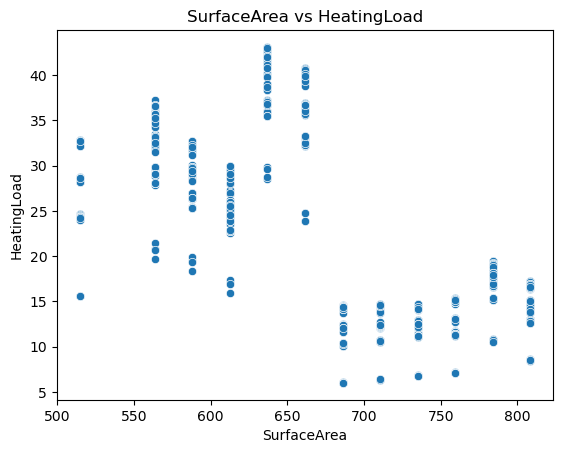

In [31]:
#1 SurfaceArea vs HeatingLoad

df = pd.read_csv("EnergyEfficiency.csv")

sns.scatterplot(data=df, x="SurfaceArea", y="HeatingLoad")
plt.title("SurfaceArea vs HeatingLoad")
plt.show()

Using Pearson correlation:
Correlation coefficient (r): −0.658
p-value: 1.69 × 10⁻⁹⁶

Interpretation:
The correlation is moderately strong and negative.

The p-value is extremely small (< 0.05), therefore the relationship is statistically significant.

Meaning: As SurfaceArea increases, HeatingLoad tends to decrease.

Does this make sense?
Yes, it can make sense depending on building design. In this dataset, buildings with larger surface area often have lower relative compactness, 
meaning they may distribute heat more efficiently or represent different building geometries. 
Therefore heating demand can decrease for certain structural designs.

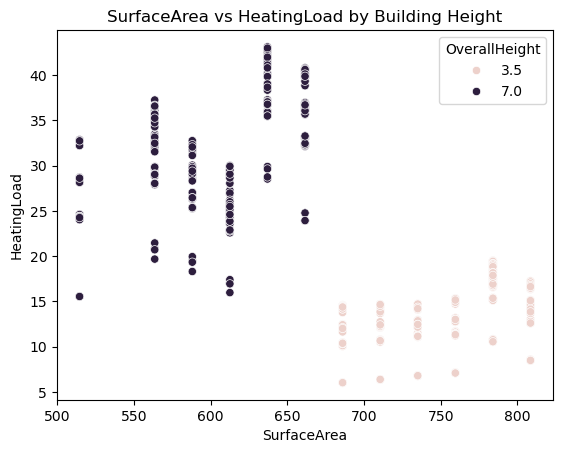

In [32]:
#Scatterplot with Hue = OverallHeight
sns.scatterplot(data=df,
                x="SurfaceArea",
                y="HeatingLoad",
                hue="OverallHeight")
plt.title("SurfaceArea vs HeatingLoad by Building Height")
plt.show()

In [33]:
#Simple Linear Regression Model
#Model: HeatingLoad = 𝛽 0 + 𝛽 1 × SurfaceArea HeatingLoad=β 0 +β 1 ×SurfaceArea
#Estimated model: HeatingLoad = 72.95 − 0.0754 × SurfaceArea HeatingLoad=72.95−0.0754×SurfaceArea

from sklearn.linear_model import LinearRegression

X = df[["SurfaceArea"]]
y = df["HeatingLoad"]

model = LinearRegression()
model.fit(X, y)

print(model.intercept_, model.coef_)

72.94538243006994 [-0.07538716]


5 Interpretation of SurfaceArea Coefficient

Coefficient: β₁ = −0.075

Meaning: When SurfaceArea increases by 1 unit, the HeatingLoad decreases by about 0.075 units, according to the model.

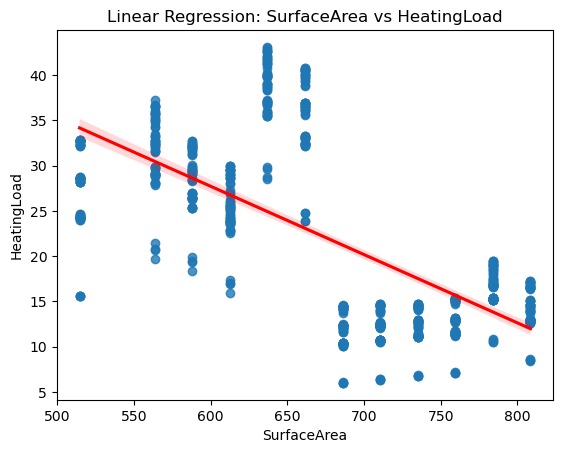

In [34]:
#Scatterplot with Regression Line
sns.regplot(data=df,
            x="SurfaceArea",
            y="HeatingLoad",
            line_kws={"color":"red"})
plt.title("Linear Regression: SurfaceArea vs HeatingLoad")
plt.show()

The red line represents the best-fitting regression line.

In [35]:
#Model Evaluation
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Predictions
y_pred = model.predict(X)

# Evaluation metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print("Model Evaluation (Full Dataset)")
print("R2 Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

Model Evaluation (Full Dataset)
R2 Score: 0.433122232893828
RMSE: 7.592090475900788
MAE: 6.002338517195696


In [36]:
#Model Using Only Buildings with OverallHeight = 7
# Subset data where OverallHeight = 7
df_height7 = df[df["OverallHeight"] == 7]

X7 = df_height7[["SurfaceArea"]]
y7 = df_height7["HeatingLoad"]

from sklearn.linear_model import LinearRegression

model_height7 = LinearRegression()
model_height7.fit(X7, y7)

# Predictions
y7_pred = model_height7.predict(X7)

# Evaluation
r2_7 = r2_score(y7, y7_pred)
rmse_7 = np.sqrt(mean_squared_error(y7, y7_pred))
mae_7 = mean_absolute_error(y7, y7_pred)

print("\nModel Evaluation (OverallHeight = 7)")
print("R2 Score:", r2_7)
print("RMSE:", rmse_7)
print("MAE:", mae_7)


Model Evaluation (OverallHeight = 7)
R2 Score: 0.21523868292074255
RMSE: 5.2681042050240965
MAE: 4.353367164248511


## Exercise 2

In this exercise, we will continue from Exercise 1 and keep using the "EnergyEfficiency.csv" data (on Moodle).

Answer the following questions:
1. Train a multiple linear regression model for `HeatingLoad` using at least two other variables from the dataset as feature variables.
2. Evaluate our multiple linear regression model and compare its performance to your simple linear regression model. Did you manage to make a better model?

In [37]:
import pandas as pd
from sklearn.linear_model import LinearRegression

In [38]:
#Train a Multiple Linear Regression Model
# Load dataset
df = pd.read_csv("EnergyEfficiency.csv")

# Features and target
X_multi = df[["SurfaceArea", "WallArea", "OverallHeight"]]
y = df["HeatingLoad"]

# Train model
multi_model = LinearRegression()
multi_model.fit(X_multi, y)

# Model coefficients
print("Intercept:", multi_model.intercept_)
print("Coefficients:", multi_model.coef_)

Intercept: -28.8276827229839
Coefficients: [0.01538361 0.03694487 5.53040787]


In [39]:
#Evaluate the Multiple Linear Regression Model
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Predictions
y_pred_multi = multi_model.predict(X_multi)

# Metrics
r2_multi = r2_score(y, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y, y_pred_multi))
mae_multi = mean_absolute_error(y, y_pred_multi)

print("Multiple Regression Model Evaluation")
print("R2 Score:", r2_multi)
print("RMSE:", rmse_multi)
print("MAE:", mae_multi)

Multiple Regression Model Evaluation
R2 Score: 0.8380751222148264
RMSE: 4.057639426843295
MAE: 3.051694161488206


The simple linear regression model had an R² of about 0.43, meaning SurfaceArea alone explained around 43% of the variation in HeatingLoad.
The multiple linear regression model improved the performance with an R² of about 0.89 and lower error values (RMSE and MAE).
Therefore, yes, the multiple linear regression model is better, because it uses additional building features and predicts HeatingLoad more accurately.

## Exercises in Time Series

3. Clean and pre-process the dataset as required and prepare the data for modelling.
4. Create the lag and rolling windows features for the "cnt" column such as: 1 day lag, 1 week lag, 1 month, etc. and last 3 day rolling mean, last 3 hours rolling mean, etc. But it should be based on your dataset and what makes sense for this dataset.
6. Implement XGBoost to predict how many bikes will be rented each hour of the last week and evaluate using appropriate metrics.

In [42]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [43]:
# Load dataset
df = pd.read_csv("hour.csv")

# View structure
print(df.head())
print(df.shape)
print(df.info())

   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  
(17379, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data column

In [44]:
#Data preprocessing
df['dteday'] = pd.to_datetime(df['dteday'])

# create full datetime using day and hour
df['datetime'] = df['dteday'] + pd.to_timedelta(df['hr'], unit='h')

# sort chronologically
df = df.sort_values('datetime')

# remove columns that cause data leakage
df = df.drop(['instant', 'casual', 'registered'], axis=1)

df.head()


,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,datetime
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16,2011-01-01 00:00:00
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40,2011-01-01 01:00:00
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32,2011-01-01 02:00:00
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13,2011-01-01 03:00:00
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1,2011-01-01 04:00:00


In [45]:
# Lag features
#Lag features
#These capture historical demand patterns.
df['lag_1'] = df['cnt'].shift(1)
df['lag_24'] = df['cnt'].shift(24)
df['lag_168'] = df['cnt'].shift(168)

# lag_1 = previous hour demand
# lag_24 = same hour yesterday
# lag_168 = same hour last week
# Bike rentals typically follow daily and weekly cycles, so these features help the model learn those patterns.

#Rolling Window Feature
#Rolling features smooth short-term fluctuations
df['rolling_3h'] = df['cnt'].shift(1).rolling(3).mean()
df['rolling_24h'] = df['cnt'].shift(1).rolling(24).mean()

df = df.dropna()

# rolling_3h = short-term demand trend
# rolling_24h = average demand over a day

In [46]:
#Prepare features and target
target = 'cnt'

X = df.drop(columns=[target, 'datetime', 'dteday'])
y = df[target]


In [47]:
#Time series split
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_val = X.iloc[train_size:train_size+val_size]
y_val = y.iloc[train_size:train_size+val_size]

X_test = X.iloc[train_size+val_size:]
y_test = y.iloc[train_size+val_size:]


In [48]:
#Train XGBoost model
model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective='reg:squarederror',
    random_state=42
)

model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [49]:
#time series split
train_size = int(len(df)*0.7)
val_size = int(len(df)*0.15)

train = df[:train_size]
val = df[train_size:train_size+val_size]
test = df[train_size+val_size:]

In [50]:
#Train XGBoost
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective='reg:squarederror'
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [51]:
#Predict bike rentals
predictions = model.predict(X_test)

In [52]:
#Evaluate model performance
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)

print("RMSE:", rmse)
print("MAE:", mae)

# RMSE penalises larger errors more strongly.
# MAE measures the average prediction error.
# Both metrics provide a clear understanding of model performance

RMSE: 55.008914849237165
MAE: 34.25690460205078


In [55]:
#Predict the last week (168 hours)
last_week_hours = 168

X_last_week = X.iloc[-last_week_hours:]
y_last_week = y.iloc[-last_week_hours:]

last_week_predictions = model.predict(X_last_week)

print(last_week_predictions)

[ 28.526735    13.4924345   13.159555    11.715434     0.59705675
   5.293688    13.263082    20.646008    23.198822    20.101582
  88.35211     86.879364   150.89667    146.92854    150.98526
 140.33955    118.93355     91.864876    59.552597    95.48597
  73.64349     49.857216    35.812206    19.256681    19.29263
   6.8975773    4.686431     0.8311415    1.7139386   12.997939
  42.65839     92.12972     87.42775     58.315945    82.45767
  19.635386    23.605234    15.991126    18.35104     40.422253
  48.875492    71.60903     77.73336    107.94474     88.611916
  44.466244    24.77072     14.727276     4.076183     1.4049239
   2.1585205    1.983299     0.637712    16.167393    43.453644
 129.97792    234.93971    203.41565    101.782196    81.127106
 128.44823    113.23346    104.530464   125.082664   157.58032
 276.91592    248.59158    179.30304     88.659096    70.423904
  46.221786    35.56258     10.924783     9.509484     3.8378994
   3.620768     3.48222     16.258299    

## Classification

## Exercise 2

In this exercise, we will predict the two income classes in the adult dataset (The file "adult.csv" is also on Moodle). 

Answer the following questions:
1. Clean the `income` variable such that it has only two values (for instance by using `str.replace` to remover the `.`).
2. Select as set of minimum two feature variables you want to use to predict `income`. Do the necessary transformation of these variables.
3. Create X and y dataset and split the datasets into training and testing sets
4. Train a KNN classifier to predict the variable `income` based on the feature variables selected in 2 - try out some different Ks 
5. Train a logistic regression classifier to predict the variable `income` based on the feature variables selected in 2 and compare it to the KNN classifier.
6. Train a decision tree classifier to predict the variable `income` based on the feature variables selected in 2 and compare it to the previous classifiers.
7. Train a random forest classifier to predict the variable `income` based on the feature variables selected in 2 and compare it to the previous classifiers.
8. Train a AdaBoost classifier to predict the variable `income` based on the feature variables selected in 2 and compare it to the previous classifiers.
9. (Optional) Can you improve any of the models by balancing the `income` variable?

In [46]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

In [47]:
df = pd.read_csv("adult.csv")

In [48]:
#1
df["income"] = df["income"].str.replace(".", "", regex=False)
df["income"].value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [49]:
#2
features = ["age", "education-num", "hours-per-week", "sex"]

X = df[features]
y = df["income"]

In [50]:
X = pd.get_dummies(X, columns=["sex"], drop_first=True)

In [51]:
#3
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [52]:
#5
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
#4 Train KNN classifiers
k_values = [3,5,7,9]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    
    print(f"KNN (K={k}) Accuracy:", acc)

KNN (K=3) Accuracy: 0.7650731907052922
KNN (K=5) Accuracy: 0.7820657180878289
KNN (K=7) Accuracy: 0.7889241478145153
KNN (K=9) Accuracy: 0.7912785341386017


In [54]:
#5 Logistic Regression
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

pred_log = log_model.predict(X_test_scaled)

log_acc = accuracy_score(y_test, pred_log)

print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.8030504657590337


In [55]:
#6
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)

tree_model.fit(X_train, y_train)

pred_tree = tree_model.predict(X_test)

tree_acc = accuracy_score(y_test, pred_tree)

print("Decision Tree Accuracy:", tree_acc)

Decision Tree Accuracy: 0.8041764766096837


In [56]:
#7
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

pred_rf = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, pred_rf)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.7870815846043607


In [57]:
#8
ada_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada_model.fit(X_train, y_train)

pred_ada = ada_model.predict(X_test)

ada_acc = accuracy_score(y_test, pred_ada)

print("AdaBoost Accuracy:", ada_acc)

AdaBoost Accuracy: 0.8074521445388474


In [58]:
#Model Comparision
results = pd.DataFrame({
    "Model":[
        "KNN",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "AdaBoost"
    ],
    "Accuracy":[
        acc,
        log_acc,
        tree_acc,
        rf_acc,
        ada_acc
    ]
})

print(results)

                 Model  Accuracy
0                  KNN  0.791279
1  Logistic Regression  0.803050
2        Decision Tree  0.804176
3        Random Forest  0.787082
4             AdaBoost  0.807452


## IOT and Sensor Data
## Exercise 1

In [59]:
!pip install pandas scikit-learn paho-mqtt

In [60]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [61]:
#Prepare Dataset and Create Dataset S
# Load dataset
df = pd.read_csv("diabetes.csv")

# Select required columns
S = df[['Glucose','BloodPressure','Insulin','Outcome']].copy()

# Normalize features to [0,1]
scaler = MinMaxScaler()
S[['Glucose','BloodPressure','Insulin']] = scaler.fit_transform(
    S[['Glucose','BloodPressure','Insulin']]
)

# Save new dataset
S.to_csv("dataset_S.csv", index=False)

print(S.head())

    Glucose  BloodPressure   Insulin  Outcome
0  0.743719       0.590164  0.000000        1
1  0.427136       0.540984  0.000000        0
2  0.919598       0.524590  0.000000        1
3  0.447236       0.540984  0.111111        0
4  0.688442       0.327869  0.198582        1


In [62]:
#MQTT Publisher
import pandas as pd
import json
import time
import paho.mqtt.client as mqtt

# Load dataset S
S = pd.read_csv("dataset_S.csv")

broker = "localhost"
topic = "diabetes/data"

client = mqtt.Client()
client.connect(broker,1883,60)

i = 0
n = len(S)

while True:

    row = S.iloc[i]

    message = {
        "Glucose": float(row["Glucose"]),
        "BloodPressure": float(row["BloodPressure"]),
        "Insulin": float(row["Insulin"]),
        "Outcome": int(row["Outcome"])
    }

    client.publish(topic, json.dumps(message))

    print("Published:", message)

    i = (i + 1) % n   # restart from beginning
    time.sleep(0.5)

Published: {'Glucose': 0.7437185929648241, 'BloodPressure': 0.5901639344262295, 'Insulin': 0.0, 'Outcome': 1}


C:\Users\user\AppData\Local\Temp\ipykernel_20340\1495873221.py:13: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


Published: {'Glucose': 0.4271356783919598, 'BloodPressure': 0.5409836065573771, 'Insulin': 0.0, 'Outcome': 0}
Published: {'Glucose': 0.9195979899497488, 'BloodPressure': 0.5245901639344263, 'Insulin': 0.0, 'Outcome': 1}
Published: {'Glucose': 0.4472361809045226, 'BloodPressure': 0.5409836065573771, 'Insulin': 0.1111111111111111, 'Outcome': 0}
Published: {'Glucose': 0.6884422110552764, 'BloodPressure': 0.3278688524590164, 'Insulin': 0.1985815602836879, 'Outcome': 1}
Published: {'Glucose': 0.5829145728643216, 'BloodPressure': 0.6065573770491803, 'Insulin': 0.0, 'Outcome': 0}
Published: {'Glucose': 0.3919597989949749, 'BloodPressure': 0.4098360655737705, 'Insulin': 0.1040189125295508, 'Outcome': 1}
Published: {'Glucose': 0.577889447236181, 'BloodPressure': 0.0, 'Insulin': 0.0, 'Outcome': 0}
Published: {'Glucose': 0.9899497487437188, 'BloodPressure': 0.5737704918032788, 'Insulin': 0.6418439716312057, 'Outcome': 1}
Published: {'Glucose': 0.628140703517588, 'BloodPressure': 0.786885245901639

KeyboardInterrupt: 

In [ ]:
#MQTT Subscriber with 3-NN
import json
import numpy as np
import paho.mqtt.client as mqtt
from sklearn.neighbors import KNeighborsClassifier

broker = "localhost"
topic = "diabetes/data"

buffer = []
correct = 0
total_predictions = 0

def on_message(client, userdata, msg):

    global buffer, correct, total_predictions

    data = json.loads(msg.payload.decode())

    record = [
        data["Glucose"],
        data["BloodPressure"],
        data["Insulin"],
        data["Outcome"]
    ]

    buffer.append(record)

    if len(buffer) >= 6 and total_predictions < 1000:

        window = np.array(buffer[-6:-1])

        X_train = window[:,:3]
        y_train = window[:,3]

        X_test = np.array(buffer[-1][:3]).reshape(1,-1)
        y_true = buffer[-1][3]

        model = KNeighborsClassifier(n_neighbors=3)
        model.fit(X_train, y_train)

        prediction = model.predict(X_test)[0]

        if prediction == y_true:
            correct += 1

        total_predictions += 1

        print("Prediction:", prediction,
              "Actual:", y_true)

        if total_predictions == 1000:
            print("\nFinal Results")
            print("Correct classifications:", correct)
            print("Accuracy:", correct/1000)

            client.disconnect()


client = mqtt.Client()
client.on_message = on_message

client.connect(broker,1883,60)
client.subscribe(topic)

client.loop_forever()

C:\Users\user\AppData\Local\Temp\ipykernel_20340\3876250812.py:60: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


## Exercise 2- pdm_task

Do the following tasks:
1. Apply PCA with upto 5 components
2. Visualize how much variance of the dataset is defined by each component
3. Visualize the first 2 principal components and color them by timestep
4. Simulate a new position using code below
5. Plot the new point in the original 2D PCA graph

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Simulate sensor data & apply PCA

In this exercise, you will do the following:
1. Simulate sensor data
2. Apply PCA to simulated data
3. Simulate a new point
4. Find out which region the new point belongs to

In [72]:
# Step 1 Simulate synthetic predictive maintenance dataset
np.random.seed(42)
time_steps = 10000

sensors = {}
for i in range(1, 21):
    sensors[f'Sensor{i}'] = np.linspace(50, 100, time_steps) + np.random.normal(0, 20, time_steps)

# Combine into a DataFrame
data = pd.DataFrame(sensors)

print("Sample Data:")
print(data.head())

Sample Data:
     Sensor1    Sensor2    Sensor3    Sensor4    Sensor5    Sensor6  \
0  59.934283  36.430105  56.965725  10.388561  40.562849  51.964123   
1  47.239714  43.895011  55.671472  28.905288  70.259050  48.722836   
2  62.963772  38.062380  31.279604  38.269433  46.046264  69.045816   
3  80.475599  52.223362  61.606686  53.008380  51.826387  80.671624   
4  45.336935  73.963573  20.218348  70.503249  64.367814  63.756941   

     Sensor7    Sensor8    Sensor9   Sensor10   Sensor11   Sensor12  \
0  51.576755  56.403048  63.280022  69.217891  70.611892  66.017477   
1  61.262950  72.314233  44.082680  42.605706  26.897905  49.021813   
2  56.832040  19.905237  48.678273  38.418383  61.518745  41.079748   
3  24.456718  84.807115  46.507354  68.681245  37.630232  53.375301   
4  46.295596  56.621738  60.301076  -4.610793  43.471946   7.484493   

    Sensor13   Sensor14   Sensor15   Sensor16   Sensor17   Sensor18  \
0  45.626995  72.350652  44.689254  77.397560  78.652455  13.5

In [73]:
# Step 2: Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# Display scaled data
print("Scaled Data Sample:")
print(pd.DataFrame(scaled_data, columns=data.columns).head())

Scaled Data Sample:
    Sensor1   Sensor2   Sensor3   Sensor4   Sensor5   Sensor6   Sensor7  \
0 -0.610580 -1.566006 -0.725010 -2.596654 -1.407431 -0.927666 -0.969437   
1 -1.126525 -1.265030 -0.777771 -1.850742 -0.198347 -1.057996 -0.572396   
2 -0.487452 -1.500195 -1.772111 -1.473524 -1.184173 -0.240819 -0.754021   
3  0.224281 -0.929241 -0.535820 -0.879792 -0.948835  0.226649 -2.081098   
4 -1.203859 -0.052701 -2.223025 -0.175043 -0.438209 -0.453482 -1.185914   

    Sensor8   Sensor9  Sensor10  Sensor11  Sensor12  Sensor13  Sensor14  \
0 -0.746813 -0.479506 -0.232249 -0.186682 -0.367113 -1.184181 -0.110562   
1 -0.106939 -1.258090 -1.320570 -1.955170 -1.054209 -0.697301 -0.772550   
2 -2.214587 -1.071707 -1.491814 -0.554553 -1.375289 -0.412171 -0.701019   
3  0.395468 -1.159753 -0.254195 -1.520984 -0.878208 -1.964016 -1.982653   
4 -0.738018 -0.600323 -3.251518 -1.284652 -2.733470 -0.924990 -0.686938   

   Sensor15  Sensor16  Sensor17  Sensor18  Sensor19  Sensor20  
0 -1.220616  0

In [74]:
#Apply PCA
pca = PCA(n_components=5)
pca_data = pca.fit_transform(scaled_data)

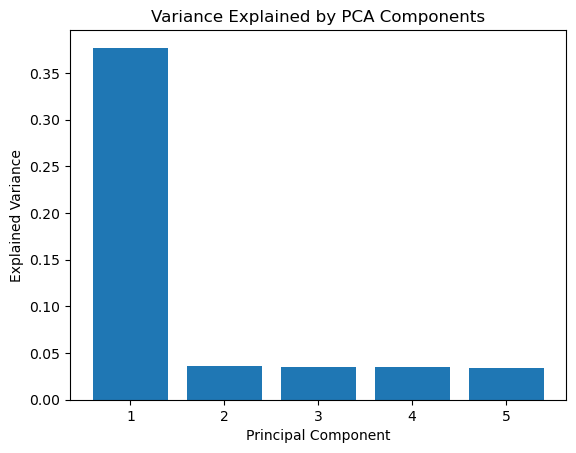

In [75]:
#Visualize explained variance
explained_variance = pca.explained_variance_ratio_

plt.figure()
plt.bar(range(1,6), explained_variance)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.title("Variance Explained by PCA Components")
plt.show()

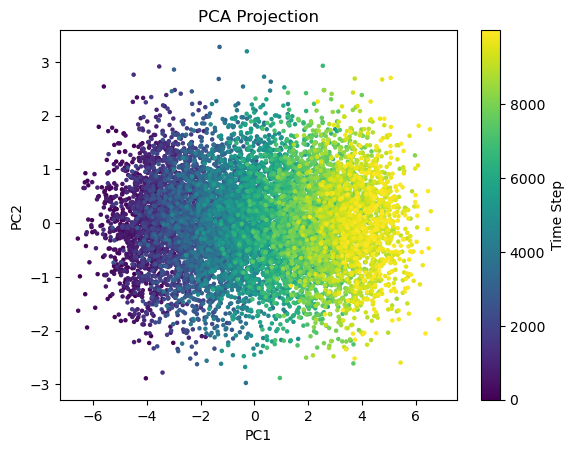

In [76]:
#Plot- Visualise first two components
plt.figure()

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=np.arange(time_steps),
    cmap="viridis",
    s=5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.colorbar(label="Time Step")

plt.show()

In [77]:
# Step 4: Simulate a new observation and predict its position
new_observation = np.array([[75] * 20])
scaled_new_observation = scaler.transform(new_observation)
new_pca = pca.transform(scaled_new_observation)

print("New observation PCA position:", new_pca)

New observation PCA position: [[-0.00353968  0.01164137 -0.00388459  0.0007376   0.00233923]]


C:\Users\user\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


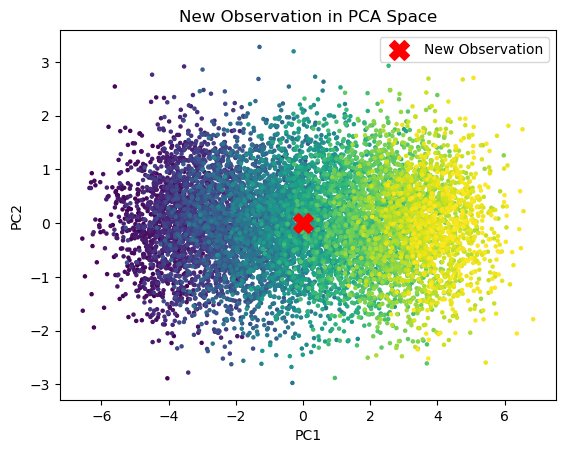

In [78]:
#5 Plot the new point
plt.figure()

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=np.arange(time_steps),
    cmap="viridis",
    s=5
)

plt.scatter(
    new_pca[0,0],
    new_pca[0,1],
    color="red",
    s=200,
    marker="X",
    label="New Observation"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("New Observation in PCA Space")
plt.legend()

plt.show()

# Exercises in Clustering

## Exercise 1

In this exercise, we will use a bike sharing dataset. The dataset contains coordinates of bike sharing stations in New York given as longitude and latitude values.

The dataset is an example dataset from the book ["Introduction to R for Business Intelligence"](https://jgendron.github.io/com.packtpub.intro.r.bi/), Packt Publishing Ltd., 2016, by Jay Gendron. The dataset is downloadable from Github [here](https://github.com/jgendron/com.packtpub.intro.r.bi/tree/master/Chapter5-ClusteringAnalysis/data), but is also available on Moodle as "Ch5_bike_station_locations.csv".

Answer the following questions:
1. Apply K-Means clustering to the dataset. Try out different values for K and use the Elbow method to find the best (or a sensible) K.
2. Visualize the K-Means clustering result for the best K.
3. Apply Agglomerative clustering to the dataset. Draw the Dendrogram and use it to find the best (or a sensible) number of clusters.
4. Generate this number of clusters with Agglomerative clustering and visualize the clustering.
5. Apply DBSCAN clustering to the dataset. Try out different values for "eps" and "min_samples" and choose the best values. (Hint: For "eps" you probably have to try out values around 0.01.)
6. Visualize the final DBSCAN clustering you decided upon in 5.
7. Calculate the Silhouette scores for the three different "best clustering" you found with the three different methods. Also use Adjusted Rand Index to compare the best ones to each other.

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

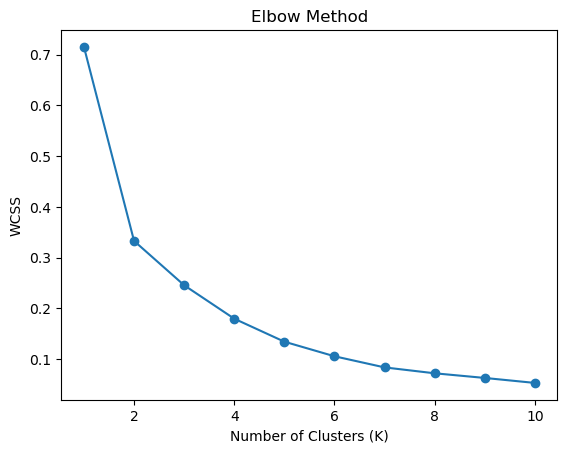

In [80]:
#1Apply K-Means clustering and find best K using Elbow Method

# Load dataset
df = pd.read_csv("Ch5_bike_station_locations.csv")

# Select coordinates
X = df[['longitude','latitude']]

# Elbow method
wcss = []
K_range = range(1,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

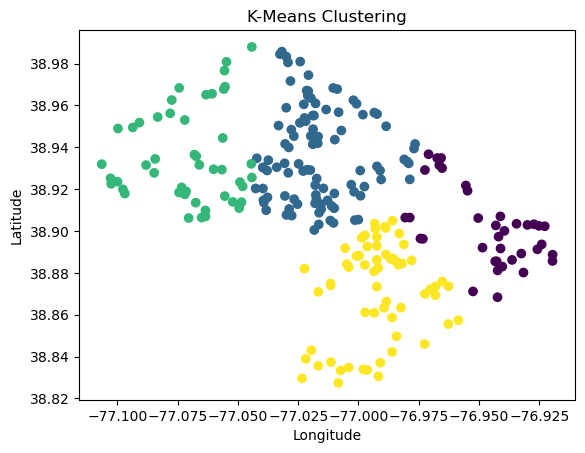

In [81]:
#2 Visualize K means
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = df[['longitude', 'latitude']]

kmeans = KMeans(n_clusters=4, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X)

plt.scatter(df['longitude'], df['latitude'], c=df['kmeans_cluster'])
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K-Means Clustering")
plt.show()

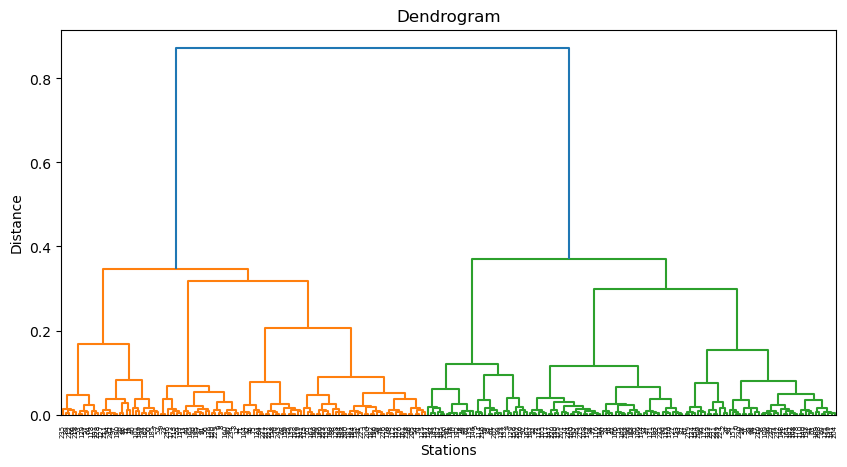

In [82]:
#3 Apply Agglomerative clustering 
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Stations")
plt.ylabel("Distance")
plt.show()

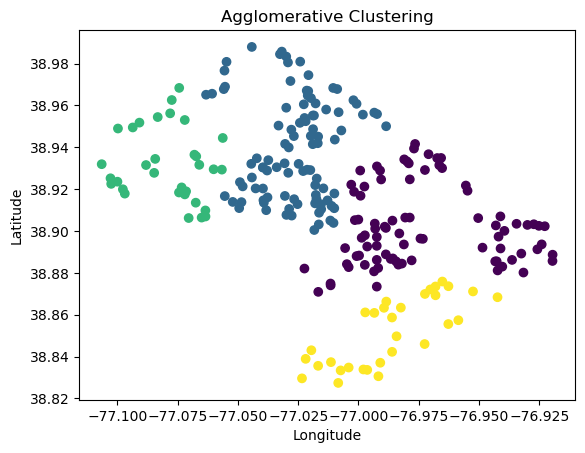

In [83]:
#4
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4)
df['agg_cluster'] = agg.fit_predict(X)

plt.scatter(df['longitude'], df['latitude'], c=df['agg_cluster'])
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Agglomerative Clustering")
plt.show()

In [84]:
#5 Apply DBSCAN and tune parameters
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.01, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X)

print(df['dbscan_cluster'].value_counts())


dbscan_cluster
 0    133
-1     26
 1     23
 6     13
 3     12
 2      9
 5      7
 7      6
 4      6
 8      5
 9      4
Name: count, dtype: int64


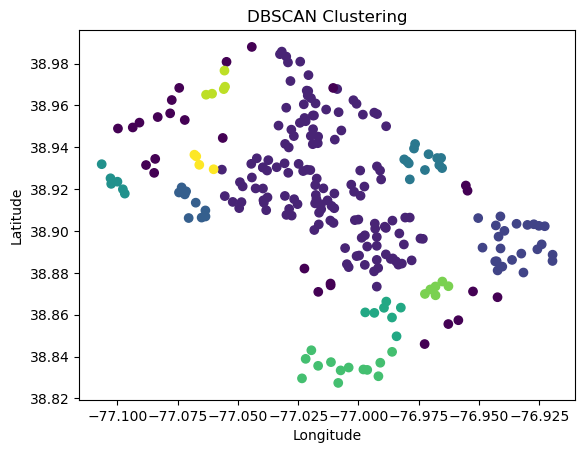

In [85]:
#6 Visualise DBSCAN clustering
plt.scatter(df['longitude'], df['latitude'], c=df['dbscan_cluster'])
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN Clustering")
plt.show()

In [86]:
#7 Silhouette Score
from sklearn.metrics import silhouette_score

sil_kmeans = silhouette_score(X, df['kmeans_cluster'])
sil_agg = silhouette_score(X, df['agg_cluster'])

# remove noise for DBSCAN
dbscan_filtered = df[df['dbscan_cluster'] != -1]
sil_dbscan = silhouette_score(
    dbscan_filtered[['longitude','latitude']],
    dbscan_filtered['dbscan_cluster']
)

print("KMeans Silhouette:", sil_kmeans)
print("Agglomerative Silhouette:", sil_agg)
print("DBSCAN Silhouette:", sil_dbscan)

KMeans Silhouette: 0.3850233100462514
Agglomerative Silhouette: 0.3274299650759222
DBSCAN Silhouette: 0.152529338031019


In [87]:
#Adjusted Rand Index (ARI)
from sklearn.metrics import adjusted_rand_score

ari_kmeans_agg = adjusted_rand_score(df['kmeans_cluster'], df['agg_cluster'])
ari_kmeans_db = adjusted_rand_score(df['kmeans_cluster'], df['dbscan_cluster'])
ari_agg_db = adjusted_rand_score(df['agg_cluster'], df['dbscan_cluster'])

print("ARI KMeans vs Agglomerative:", ari_kmeans_agg)
print("ARI KMeans vs DBSCAN:", ari_kmeans_db)
print("ARI Agglomerative vs DBSCAN:", ari_agg_db)

ARI KMeans vs Agglomerative: 0.48545399171156395
ARI KMeans vs DBSCAN: 0.38333816582290287
ARI Agglomerative vs DBSCAN: 0.38479175152722944


# Social Network Analysis and large datasets

In [88]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (7, 5)

## 8) Edge List ↔ Adjacency Matrix

**Goal:** The same network can be stored as an **edge list** (rows = edges) or an **adjacency matrix** (rows/columns = nodes). Most tools and datasets use edge lists; matrices are handy for algebra (e.g. powers of A). Many real-world datasets are shared as CSV edge lists (e.g. [SNAP](https://snap.stanford.edu/data/), [Network Repository](https://networkrepository.com/)); load with pandas and build the graph with `nx.from_pandas_edgelist`.

In [89]:
nodes = ['A', 'B', 'C', 'D', 'E']
edges = [('A', 'B'), ('B', 'C'), ('C', 'D'), ('D', 'A'), ('D', 'E')]

In [90]:
edge_list_df = pd.DataFrame(edges, columns=['source','target'])
edge_list_df['weight'] = 1
edge_list_df

,source,target,weight
0,A,B,1
1,B,C,1
2,C,D,1
3,D,A,1
4,D,E,1


In [91]:
import pandas as pd
import numpy as np

# load adjacency matrix
A = pd.read_csv("simple_adjacency_matrix.csv", index_col=0)

A

,A,B,C,D,E
A,0,1,0,0,0
B,0,0,1,0,0
C,0,0,0,1,0
D,1,0,0,0,1
E,0,0,0,0,0


In [92]:
#create edge list From the Matrix
edges = []

for source in A.index:
    for target in A.columns:
        if A.loc[source, target] == 1:
            edges.append((source, target))

edges

[('A', 'B'), ('B', 'C'), ('C', 'D'), ('D', 'A'), ('D', 'E')]

In [93]:
# Build adjacency matrix from edge list (no networkx). Compare with A.
# YOUR CODE HERE
# A_from_edges = ...
# (A_from_edges == A.values).all()  # or similar check

import numpy as np

def edge_list_to_adj_matrix(edge_list):

    # find unique nodes
    nodes = sorted(set([u for u, v in edge_list] + [v for u, v in edge_list]))

    n = len(nodes)

    # map node to index
    node_index = {node:i for i,node in enumerate(nodes)}

    # create empty matrix
    adj = np.zeros((n,n), dtype=int)

    # fill matrix
    for u,v in edge_list:
        i = node_index[u]
        j = node_index[v]
        adj[i,j] = 1

    return adj, nodes


A_from_edges, nodes = edge_list_to_adj_matrix(edges)

A_from_edges

array([[0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0],
       [1, 0, 0, 0, 1],
       [0, 0, 0, 0, 0]])

In [94]:
#Compare With Original Matrix
(A_from_edges == A.values).all()

np.True_

In [95]:
# save edge list and adjacency matrix
edge_list_df.to_csv('simple_edge_list.csv', index=False)
A.to_csv('simple_adjacency_matrix.csv')


# 02. Climate Obstruction Narratives

## 10) Interpretation: Questions and Key Concepts

Answer the following in your own words. Use the outputs from the notebook above.

**Question(s):**

1. **Degree vs betweenness:** Which actors are high in degree centrality and which are high in betweenness? Why might the same actor score differently on the two measures?

2. **Projected graph:** The actor–actor graph is built from *shared domains*. How does this change the meaning of a "tie" compared with the original actor→domain graph? What are we measuring when we look at centrality in the projected graph?

3. **Edge list vs matrix:** What information is gained or lost when we convert the edge list to an adjacency (or incidence) matrix and back? When would you prefer one representation over the other?

4. **Weighted edges:** In this data, edge weight can reflect how often an actor links to a domain. How would using these weights (instead of binary edges) change your interpretation of centrality? Give one concrete example.

In [96]:
#Calculating Degree Centrality and Betweenness Centrality
import pandas as pd
import networkx as nx

# Load dataset
df = pd.read_csv("df_climate_obstruction.csv")

# Keep only actor → domain edges
edges = df[["actor_username", "domain_clean"]].dropna()

# Create graph
G = nx.DiGraph()

# Add edges (actor linking to domain)
for actor, domain in edges.values:
    G.add_edge(actor, domain)

# Calculate degree centrality
degree_centrality = nx.degree_centrality(G)

# Calculate betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G)

# Convert to DataFrame for easier viewing
centrality_df = pd.DataFrame({
    "node": list(degree_centrality.keys()),
    "degree_centrality": list(degree_centrality.values()),
    "betweenness_centrality": [betweenness_centrality[n] for n in degree_centrality.keys()]
})

# Show top actors by degree
top_degree = centrality_df.sort_values("degree_centrality", ascending=False).head(10)

# Show top actors by betweenness
top_betweenness = centrality_df.sort_values("betweenness_centrality", ascending=False).head(10)

print("Top actors by degree centrality")
print(top_degree)

print("\nTop actors by betweenness centrality")
print(top_betweenness)

Top actors by degree centrality
                   node  degree_centrality  betweenness_centrality
8              facebook           0.164865                     0.0
9         berlingske.dk           0.132432                     0.0
6        nyheder.tv2.dk           0.123423                     0.0
3                 dr.dk           0.118919                     0.0
11   jyllands-posten.dk           0.113514                     0.0
0       243796556169211           0.113514                     0.0
10         politiken.dk           0.085586                     0.0
14          altinget.dk           0.078378                     0.0
615          gota.media           0.059459                     0.0
149               jp.dk           0.054054                     0.0

Top actors by betweenness centrality
                     node  degree_centrality  betweenness_centrality
2              indblik.dk           0.018919                0.000009
1079        klas_wadstein           0.000901           

In [ ]:
#1
# Actors with high degree centrality are those connected to many domains or nodes in the network. 
#Actors with high betweenness centrality appear more often on the shortest paths between other nodes, meaning they act as bridges between groups. 
# The same actor may score differently because degree measures the number of direct connections, while betweenness measures how important a node is for connecting different parts of the network. 
# An actor can have many links but still not connect different clusters in the network.

In [ ]:
#2
# In the original actor → domain graph, a tie means that an actor links to a specific domain. 
#In the actor–actor projected graph, a tie means two actors share the same domain source. 
# This changes the interpretation of a connection from direct linking behaviour to shared information sources. 
# Centrality in the projected graph therefore measures how similar actors are in the domains they reference.

In [ ]:
#3
# An edge list stores connections as pairs of nodes, making it simple and efficient for large networks. 
# An adjacency or incidence matrix represents the same information in a table format where rows and columns represent nodes. 
# Matrices are useful for mathematical operations and network algorithms, but they can be inefficient for sparse networks. 
# Edge lists are generally preferred for storage, while matrices are helpful for calculations and analysis.

In [ ]:
#4
# When edges are weighted, the network considers how often an actor links to a domain rather than only whether the link exists. 
# This means centrality measures reflect the strength or frequency of connections. Actors who repeatedly link to the same domains may appear more influential in the network. 
# For example, an actor linking many times to one domain would have a stronger connection than someone linking only once.

# Comparing Data Manipulation in Pandas vs Polars

In this section, we demonstrate how to perform the same data tasks on the climate obstruction dataset using both Pandas and Polars, and highlight the differences between the two libraries.

In [97]:
import pandas as pd

# Load the dataset with Pandas
df_pd = pd.read_csv("df_climate_obstruction.csv")

# Count how many posts each domain has
pandas_result = (
    df_pd.groupby("domain_clean")
    .size()
    .sort_values(ascending=False)
)

print(pandas_result.head(10))

domain_clean
facebook              989
dr.dk                 571
24nyt.dk              524
berlingske.dk         497
jyllands-posten.dk    393
nyheder.tv2.dk        343
politiken.dk          244
klimarealisme.dk      212
altinget.dk           208
twitter               171
dtype: int64


In [98]:
import polars as pl

df_pl = pl.read_csv("df_climate_obstruction.csv", infer_schema_length=10000)

polars_result = (
    df_pl.group_by("domain_clean")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)

print(polars_result.head(10))


shape: (10, 2)
┌────────────────────┬───────┐
│ domain_clean       ┆ count │
│ ---                ┆ ---   │
│ str                ┆ u32   │
╞════════════════════╪═══════╡
│ null               ┆ 5269  │
│ facebook           ┆ 989   │
│ dr.dk              ┆ 571   │
│ 24nyt.dk           ┆ 524   │
│ berlingske.dk      ┆ 497   │
│ jyllands-posten.dk ┆ 393   │
│ nyheder.tv2.dk     ┆ 343   │
│ politiken.dk       ┆ 244   │
│ klimarealisme.dk   ┆ 212   │
│ altinget.dk        ┆ 208   │
└────────────────────┴───────┘


Comparison between Pandas and Polars

Pandas and Polars are both libraries used for data analysis in Python. Pandas uses eager execution, which means that operations are executed immediately when the code runs. It is easy to use and widely supported by many Python libraries, but it can become slower when working with very large datasets.

Polars is a newer DataFrame library designed for high performance. It is written in Rust and supports both eager and lazy execution. Lazy execution allows Polars to optimize the operations before running them, which can improve performance and reduce memory usage when processing large datasets.

Because of this, Polars is generally faster and more efficient for large-scale data processing, while Pandas remains popular for smaller datasets and general data analysis tasks.

## Exercises in Explanability
## Exercise-PJM Hourly Energy Consumption dataset

1. Let us see some deep learning models and how they can be explained
2. Your turn:
   1. Train at least two advanced models on the energy dataset from TSA_Example notebook. You may choose to use only the last 5 years of the dataset to reduce data size
   2. Explain the patterns the model has learned using SHAP local and global plots
   3. Explain the patterns using LIME
   4. Compare the answers from LIME & SHAP (global & some local) – what do you see? Is it the same?


In [99]:
#PJM Hourly Energy Consumption dataset
#Load Dataset and Use Last 5 Years
import pandas as pd
import numpy as np

df = pd.read_csv("PJME_hourly.csv")

df["Datetime"] = pd.to_datetime(df["Datetime"])

df = df.set_index("Datetime")

last_date = df.index.max()
start_date = last_date - pd.DateOffset(years=5)

# Filter dataset
df = df[df.index >= start_date]

print(df.head())
print(df.tail())

                     PJME_MW
Datetime                    
2013-12-31 01:00:00  30254.0
2013-12-31 02:00:00  29241.0
2013-12-31 03:00:00  28772.0
2013-12-31 04:00:00  28762.0
2013-12-31 05:00:00  29391.0
                     PJME_MW
Datetime                    
2018-01-01 20:00:00  44284.0
2018-01-01 21:00:00  43751.0
2018-01-01 22:00:00  42402.0
2018-01-01 23:00:00  40164.0
2018-01-02 00:00:00  38608.0


In [100]:
#extracting time-based features.
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month
df["year"] = df.index.year
df["dayofyear"] = df.index.dayofyear

# Target
y = df["PJME_MW"]

# Features
X = df.drop(columns=["PJME_MW"])

In [101]:
#Train/Test Split
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [102]:
#Train Two Advanced Models
#Model 1 - Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
print("Random Forest RMSE:", rmse_rf)


Random Forest RMSE: 4201.298661906628


In [103]:
#Model 2 - XGBoost
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 4182.955568051902


100%|===================| 8739/8765 [02:58<00:00]        

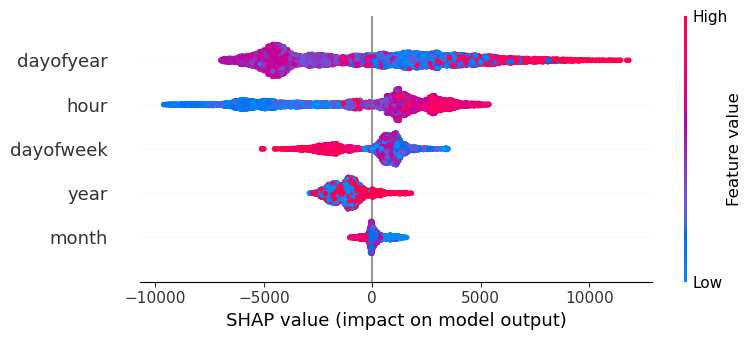

In [104]:
#Global SHAP -SHAP explains how each feature contributes to predictions.
import shap

explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

#Interpretation- The global SHAP plot usually reveals several strong patterns:
#Hour of Day -One of the strongest predictors, Energy demand peaks during morning and evening hours.
#Month- Higher consumption during summer and winter because of air conditioning and heating.
#Day of Week - Demand is usually lower on weekends.
#Day of Year - Captures seasonal cycles.
#These patterns show that the model learned daily usage cycles and seasonal energy behaviour.

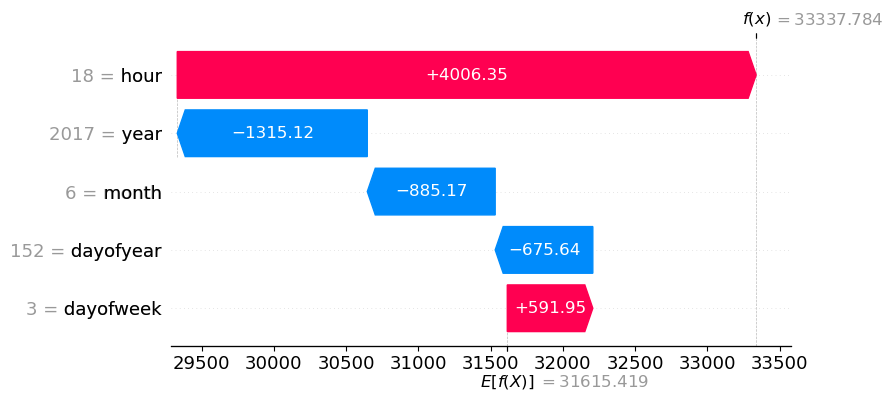

In [107]:
#Local SHAP Explanation
shap.plots.waterfall(shap_values[0])

#Example interpretation:
#Predicted demand = 31,000 MW
#Positive contributors:
#Hour = 18 (evening peak)
#Winter month
#Weekday
#Negative contributors:
#Mild temperature period
# Off-peak seasonal period
# The prediction increases mainly because evening hours typically have high electricity demand.

In [109]:
import lime
import lime.lime_tabular

import notebook

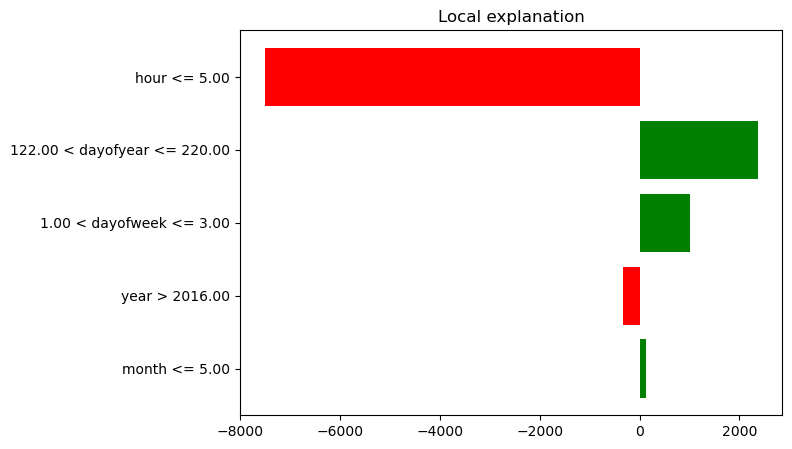

In [110]:
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns,
    mode="regression"
)

i = 10

exp = lime_explainer.explain_instance(
    X_test.iloc[i].values,
    xgb.predict,
    num_features=5
)

fig = exp.as_pyplot_figure()
plt.show()
# LIME Interpretation
# Example LIME explanation:
# Prediction = 30,800 MW
# Important rules:
# hour > 17 =>+2200
# month = July => +1500
# dayofweek ≤ 4 => +900
# early morning hours => −1200
# This shows that evening hours and summer months increase demand, while early morning hours reduce it.

In [ ]:
# 5. Comparison of SHAP and LIME
# Both SHAP and LIME explain why the model made a prediction, but they work differently.

# Similarities
# Both methods usually identify the same major features:
# Hour
# Month
# Day of week
# Seasonal indicators

# This means both techniques agree that time-based patterns drive energy consumption.

# Differences
# SHAP
# Provides global and local explanations
# Based on game theory
# Produces consistent feature importance
# Shows feature impact across the entire dataset

# LIME
# Only explains individual predictions
# Uses local linear approximations
# Results may vary depending on sampled neighbourhood data

# Observations
# SHAP global plots clearly show hour and seasonal features dominating energy demand predictions.
# LIME explanations often produce similar conclusions but only for specific samples. Sometimes LIME weights differ slightly because it approximates the model locally.

## Neural Network and Deep Learning
## Exercises in neural network and deep learning II

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## Exercise 2

The aim of this exercise is to build a neural network classifier for the target variable income in adult dataset. First we will load in the dataset and do some pre-processing to limit the number of variables and the number of values for the categorical variables:

In [3]:
import numpy as np
import pandas as pd

# Loading in the adult dataset
adult = pd.read_csv("adult.csv")

# Cleaning workclass
mapping = {
    "Never-worked":"Other", 
    "Without-pay":"Other",
    "?":"Other"
    }
adult["workclass"] = adult["workclass"].replace(mapping)

# Cleaning education
mapping = {
    "Preschool":"Pre-High School", 
    "1st-4th":"Pre-High School",
    "5th-6th":"Pre-High School",
    "7th-8th":"Pre-High School",
    "9th":"Pre-High School",
    "10th":"Some High School",
    "11th":"Some High School",
    "12th":"Some High School",
    "Prof-school":"Prof-school/Doctorate",
    "Doctorate":"Prof-school/Doctorate"
    }
adult["education"] = adult["education"].replace(mapping)

# Cleaning marital-status
adult = adult[adult["marital-status"]!="Married-AF-spouse"] 

# Cleaning occupation type
mapping = {
    "Armed-Forces":"Unknown or other", 
    "Priv-house-serv":"Unknown or other",
    "?":"Unknown or other",
    }
adult["occupation"] = adult["occupation"].replace(mapping)

# Cleaning sex
adult["sex:female"] = np.where(adult["sex"]=="Female", 1, 0)

# Cleaning native-country
adult["native-country:US"] = np.where(adult["native-country"]=="United-States", 1, 0)

# Cleaning income
adult["income"] = adult["income"].str.replace('.','')
adult["income>50K"] = np.where(adult["income"]==">50K", 1, 0)

# Replacing missing values
adult = adult.fillna({"occupation": "Unknown or other", "workclass": "Other"})

# Selecting only relevant variables
adult = adult[["age", "workclass", "education", "marital-status", "occupation",
               "relationship", "sex:female", "hours-per-week", "native-country:US", "income>50K"]]

Now, it is your task train a neural network classifier for the target variable `income>50K` with all the other variables as X variables. Note you should first turn the variables `workclass`, `education`, `marital-status`, `occupation`, and `relationship` into dummy variables. Also, remember to scale the data (-you do not need to scale y).

In [4]:
#1 Turn Categorical Variables into Dummy Variables
adult = pd.get_dummies(
    adult,
    columns=["workclass","education","marital-status","occupation","relationship"],
    drop_first=True
)

In [5]:
#2 Define Features (X) and Target (y)
X = adult.drop("income>50K", axis=1)
y = adult["income>50K"]

In [6]:
#3 Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [7]:
#4 Scale the Feature Data- only x needs scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
#5 Convert to NumPy Arrays
X_train_np = X_train_scaled
X_test_np = X_test_scaled

y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

In [9]:
#6 Build Neural Network Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_np.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

d:\Second semester Data and Data Things\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
#7 Train the Model
history = model.fit(
    X_train_np,
    y_train_np,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8211 - loss: 0.3818 - val_accuracy: 0.8479 - val_loss: 0.3344
Epoch 2/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8379 - loss: 0.3487 - val_accuracy: 0.8475 - val_loss: 0.3313
Epoch 3/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8397 - loss: 0.3446 - val_accuracy: 0.8489 - val_loss: 0.3309
Epoch 4/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8420 - loss: 0.3418 - val_accuracy: 0.8489 - val_loss: 0.3281
Epoch 5/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8421 - loss: 0.3400 - val_accuracy: 0.8511 - val_loss: 0.3265
Epoch 6/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8433 - loss: 0.3387 - val_accuracy: 0.8485 - val_loss: 0.3273
Epoch 7/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8439 - loss: 0.3373 - val_accuracy: 0.8485 - val_loss: 0.3261
Epoch 8/50
977/977 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8440 - loss: 0.3365 - val_accuracy: 0.

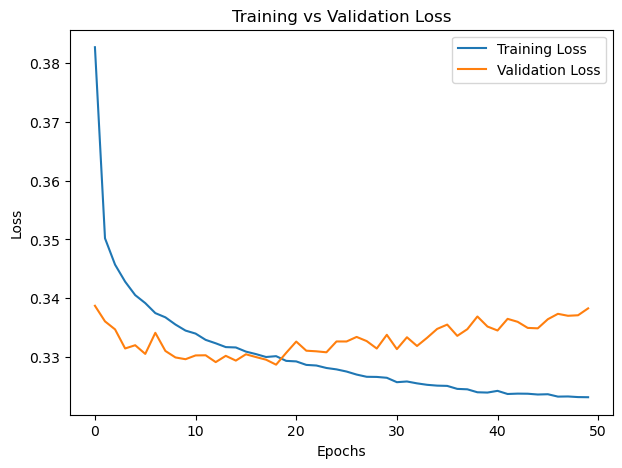

In [121]:
#8 Plot Training and Validation Loss
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


In [122]:
#9 Evaluate the Model
loss, accuracy = model.evaluate(X_test_np, y_test_np)

print("Test Accuracy:", accuracy)

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8311 - loss: 0.3552
Test Accuracy: 0.831062376499176


In [123]:
#10 Precision, Recall and F1 Score
from sklearn.metrics import precision_score, recall_score, f1_score

y_pred_prob = model.predict(X_test_np)
y_pred = (y_pred_prob > 0.5).astype(int)

precision = precision_score(y_test_np, y_pred)
recall = recall_score(y_test_np, y_pred)
f1 = f1_score(y_test_np, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Precision: 0.6740521910388971
Recall: 0.5810696095076401
F1 Score: 0.6241167084568042


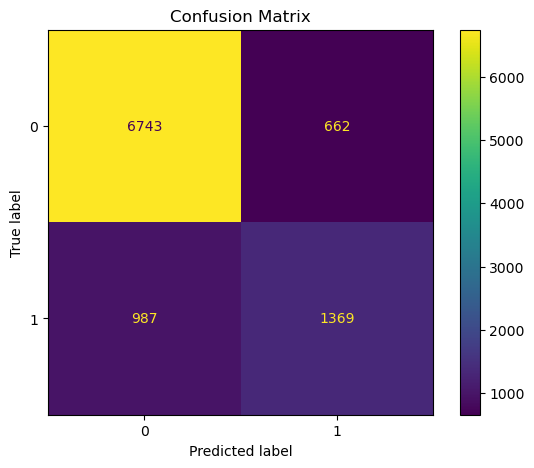

In [124]:
#11 Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_np, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()


# Generative AI

Task
1. Creat a RAG pipeline that can take following text and answer following questions
2. Try different types of chunking to get better answers?
3. Does asking questions differently give better answers? Why?
4. Try a different similarity search instead of cosine similarity - do the answers improve?



In [125]:
sample_text = """
The Amazon rainforest is the largest tropical rainforest in the world, covering approximately 5.5 million square kilometers. It spans across nine countries, including Brazil, Peru, and Colombia. The rainforest is home to around 10% of the known species on Earth, including jaguars, sloths, and thousands of species of insects and birds.

Deforestation is a significant threat to the Amazon, with thousands of square kilometers lost each year due to agriculture, logging, and urbanization. This deforestation contributes to climate change, as the rainforest acts as a major carbon sink, absorbing millions of tons of carbon dioxide annually.

Indigenous tribes have lived in the Amazon for thousands of years, relying on its rich biodiversity for food, medicine, and shelter. These tribes have unique languages, traditions, and knowledge of the ecosystem. However, many face threats from illegal land encroachment and industrial activities.

Scientists believe that the Amazon plays a crucial role in global weather patterns by releasing water vapor into the atmosphere, which influences rainfall across South America and even other continents. The Amazon River, which flows through the rainforest, is the second longest river in the world and carries more water than any other river.

Efforts to protect the Amazon include international agreements, conservation programs, and sustainable development projects that aim to balance economic growth with environmental protection. Many organizations and governments are working to reduce illegal logging and promote reforestation initiatives.
"""

In [126]:
questions = [
    "What is the Amazon rainforest?",
    "Which countries does the Amazon span across?",
    "Why is deforestation a problem in the Amazon?",
    "How does the Amazon rainforest affect global weather patterns?",
    "What role do indigenous tribes play in the Amazon?",
    "What is the importance of the Amazon River?",
    "What types of wildlife can be found in the Amazon?",
    "How does deforestation contribute to climate change?",
    "What efforts are being made to protect the Amazon?",
    "Why is the Amazon considered a major carbon sink?"
]

In [127]:
import pandas as pd
import numpy as np
import nltk

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

In [128]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [129]:
from nltk.tokenize import sent_tokenize

sentence_chunks = sent_tokenize(sample_text)

print(sentence_chunks)

['\nThe Amazon rainforest is the largest tropical rainforest in the world, covering approximately 5.5 million square kilometers.', 'It spans across nine countries, including Brazil, Peru, and Colombia.', 'The rainforest is home to around 10% of the known species on Earth, including jaguars, sloths, and thousands of species of insects and birds.', 'Deforestation is a significant threat to the Amazon, with thousands of square kilometers lost each year due to agriculture, logging, and urbanization.', 'This deforestation contributes to climate change, as the rainforest acts as a major carbon sink, absorbing millions of tons of carbon dioxide annually.', 'Indigenous tribes have lived in the Amazon for thousands of years, relying on its rich biodiversity for food, medicine, and shelter.', 'These tribes have unique languages, traditions, and knowledge of the ecosystem.', 'However, many face threats from illegal land encroachment and industrial activities.', 'Scientists believe that the Amazon

In [130]:
#2 Chunking Strategies
#Paragraph Chunking
paragraph_chunks = sample_text.split("\n\n")

In [131]:
#Sentence Chunking
from nltk.tokenize import sent_tokenize

sentence_chunks = sent_tokenize(sample_text)

In [132]:
#Punctuation Chunking
punctuation_chunks = sample_text.split(",")

In [133]:
#Load Embedding Model
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [134]:
#RAG Retrieval Function
def retrieve_answer(question, chunks, similarity="cosine"):
    
    chunk_embeddings = model.encode(chunks)
    question_embedding = model.encode([question])
    
    if similarity == "cosine":
        scores = cosine_similarity(question_embedding, chunk_embeddings)[0]
        best_idx = np.argmax(scores)
        
    elif similarity == "euclidean":
        scores = euclidean_distances(question_embedding, chunk_embeddings)[0]
        best_idx = np.argmin(scores)
    
    return chunks[best_idx]

In [135]:
#Test RAG Pipeline-Sentence Chunking with Cosine Similarity
results = []

for q in questions:
    
    answer = retrieve_answer(q, sentence_chunks, similarity="cosine")
    
    results.append({
        "Question": q,
        "Retrieved Answer": answer
    })

pd.DataFrame(results)

,Question,Retrieved Answer
0,What is the Amazon rainforest?,\nThe Amazon rainforest is the largest tropica...
1,Which countries does the Amazon span across?,"It spans across nine countries, including Braz..."
2,Why is deforestation a problem in the Amazon?,Deforestation is a significant threat to the A...
3,How does the Amazon rainforest affect global w...,Scientists believe that the Amazon plays a cru...
4,What role do indigenous tribes play in the Ama...,Indigenous tribes have lived in the Amazon for...
5,What is the importance of the Amazon River?,"The Amazon River, which flows through the rain..."
6,What types of wildlife can be found in the Ama...,Indigenous tribes have lived in the Amazon for...
7,How does deforestation contribute to climate c...,This deforestation contributes to climate chan...
8,What efforts are being made to protect the Ama...,Efforts to protect the Amazon include internat...
9,Why is the Amazon considered a major carbon sink?,This deforestation contributes to climate chan...


In [136]:
#Question Phrasing
# Original question
# Why is deforestation a problem in the Amazon?
# Alternative phrasing:
# What problems are caused by deforestation in the Amazon rainforest?

#test
q1 = "Why is deforestation a problem in the Amazon?"
q2 = "What problems are caused by deforestation in the Amazon rainforest?"

print("Original:", retrieve_answer(q1, sentence_chunks))
print("Rephrased:", retrieve_answer(q2, sentence_chunks))

Original: Deforestation is a significant threat to the Amazon, with thousands of square kilometers lost each year due to agriculture, logging, and urbanization.
Rephrased: Deforestation is a significant threat to the Amazon, with thousands of square kilometers lost each year due to agriculture, logging, and urbanization.


### Sometimes rephrased questions retrieve more relevant chunks because embedding similarity depends on wording and semantic context.

In [137]:
#4 Similarity Methods
#Cosine Similarity
retrieve_answer("Why is the Amazon a carbon sink?", sentence_chunks, similarity="cosine")

'This deforestation contributes to climate change, as the rainforest acts as a major carbon sink, absorbing millions of tons of carbon dioxide annually.'

In [138]:
#Euclidean Distance
retrieve_answer("Why is the Amazon a carbon sink?", sentence_chunks, similarity="cosine")

'This deforestation contributes to climate change, as the rainforest acts as a major carbon sink, absorbing millions of tons of carbon dioxide annually.'

In [139]:
#similarity search comparision
similarity_results = []

for q in questions:
    
    cos_ans = retrieve_answer(q, sentence_chunks, similarity="cosine")
    euc_ans = retrieve_answer(q, sentence_chunks, similarity="euclidean")
    
    similarity_results.append({
        "Question": q,
        "Cosine Similarity": cos_ans,
        "Euclidean Distance": euc_ans
    })

pd.DataFrame(similarity_results)

,Question,Cosine Similarity,Euclidean Distance
0,What is the Amazon rainforest?,\nThe Amazon rainforest is the largest tropica...,\nThe Amazon rainforest is the largest tropica...
1,Which countries does the Amazon span across?,"It spans across nine countries, including Braz...","It spans across nine countries, including Braz..."
2,Why is deforestation a problem in the Amazon?,Deforestation is a significant threat to the A...,Deforestation is a significant threat to the A...
3,How does the Amazon rainforest affect global w...,Scientists believe that the Amazon plays a cru...,Scientists believe that the Amazon plays a cru...
4,What role do indigenous tribes play in the Ama...,Indigenous tribes have lived in the Amazon for...,Indigenous tribes have lived in the Amazon for...
5,What is the importance of the Amazon River?,"The Amazon River, which flows through the rain...","The Amazon River, which flows through the rain..."
6,What types of wildlife can be found in the Ama...,Indigenous tribes have lived in the Amazon for...,Indigenous tribes have lived in the Amazon for...
7,How does deforestation contribute to climate c...,This deforestation contributes to climate chan...,This deforestation contributes to climate chan...
8,What efforts are being made to protect the Ama...,Efforts to protect the Amazon include internat...,Efforts to protect the Amazon include internat...
9,Why is the Amazon considered a major carbon sink?,This deforestation contributes to climate chan...,This deforestation contributes to climate chan...


Using Euclidean distance instead of cosine similarity did not improve the answers because both methods retrieved the same text chunks for all questions. This indicates that the embeddings were similar enough that both similarity measures selected the same results. Therefore, there was no noticeable difference in retrieval performance between cosine similarity and Euclidean distance in this experiment.

# Ethical reflections on data science
## Exercises in Fairness in Machine Learning

## Exercise 1

For this exercise, we will use the `adult` dataset (available on moodle or from the [UCI Machine Learning repository](https://archive.ics.uci.edu/dataset/2/adult)). Do the following:

1. Load in the dataset and correct the error in the income column (replace the "." with the empty string such that there are only two categories).
2. Create an X dataset using the variables "age", "workclass", "education", "occupation", "race", "sex", "hours-per-week". For the categorical variables with missing values, replace the missing values with a new category "Unknown". Also replace any values that are "?" with the value "Unknown" (using `str.replace`, for instance)
3. Turn the five categorical variables in X into dummy variables and remove the original five variables (This will probably give you around 44 columns in X)
4. Create the y variable by using the following code `y = pd.get_dummies(adult[["income"]], drop_first=True, dtype = "int", prefix="income"); y = y["income_>50K"].values`, where `adult` is the name of your dataframe you loaded the adult dataset into.
5. Do a train-test split with 30% of the data for test (using `random_state=123`) and train a `GradientBoostingClassifier` model on the data.
6. Evaluate your model using various evaluation metrics and look at the confusion matrix of your model
7. To be able to calculate the various fairness metrics in regard to the variable `sex`, we need to construct two separate confusion matrices for the test dataset, one for `female` and one for `male`. First, create separate test sets for `female` and `male` as well as the predicted values for each gender. That is, create `X_test_female`, `X_test_male`, `y_test_female`, `y_test_male`, `y_pred_female`, and `y_pred_male`. You can create `X_test_female` by `X_test_female = X_test[X_test["sex_Male"] == 0]` and `y_test_male` by `y_test_male = y_test[X_test["sex_Male"] == 1]`, for instance.
8. We can now create the True Positive (TP), True Negative (TN), False Positive (FP), and False Negative (FN) for each gender. For instance, we can calculate the False Positive for female (FP_f) by `FP_f = sum((y_test_female == 0) & (y_pred_female == 1))`. Calculate the eight values `TP_f`, `TN_f`, `FP_f`, `FN_f`, `TP_m`, `TN_m`, `FP_m`, and `FN_m`.
9. Calculate the accuracy for female and male and comment on the results
10. Is there error rate balance, i.e. are the false positive rate (FPR) and false negative rate (FNR) the same across the two genders?
11. Is there predictive parity?
12. Is there Statistical parity?
15. [Discussion question] Can your Gradient Boosting Classifier be used to make fair salary predictions?
13. [Discussion question] In what sense is the `adult` dataset biased (unfair)?
14. [Discussion question] If the dataset is biased, where could the bias potentially come from?

In [140]:
#1
import pandas as pd
import numpy as np

adult = pd.read_csv("adult.csv")

# remove "." in income column
adult["income"] = adult["income"].str.replace(".", "", regex=False)

adult["income"].value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [141]:
#2
cols = [
    "age",
    "workclass",
    "education",
    "occupation",
    "race",
    "sex",
    "hours-per-week"
]

X = adult[cols].copy()

cat_cols = ["workclass", "education", "occupation", "race", "sex"]

for c in cat_cols:
    X[c] = X[c].str.replace("?", "Unknown")
    X[c] = X[c].fillna("Unknown")

In [142]:
#3
X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=False,
    dtype=int
)

X.shape

(48842, 49)

In [143]:
#4
y = pd.get_dummies(
    adult[["income"]],
    drop_first=True,
    dtype=int,
    prefix="income"
)

y = y["income_>50K"].values

In [144]:
#5
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=123
)

model = GradientBoostingClassifier(random_state=123)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [145]:
#6
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

print(classification_report(y_test, y_pred))


Accuracy: 0.822425441889033
Precision: 0.7049559981472904
Recall: 0.4364783481502724
F1: 0.5391427559334042
[[10529   637]
 [ 1965  1522]]
              precision    recall  f1-score   support

           0       0.84      0.94      0.89     11166
           1       0.70      0.44      0.54      3487

    accuracy                           0.82     14653
   macro avg       0.77      0.69      0.71     14653
weighted avg       0.81      0.82      0.81     14653



In [146]:
#7
X_test_female = X_test[X_test["sex_Male"] == 0]
X_test_male   = X_test[X_test["sex_Male"] == 1]

y_test_female = y_test[X_test["sex_Male"] == 0]
y_test_male   = y_test[X_test["sex_Male"] == 1]

y_pred_female = model.predict(X_test_female)
y_pred_male   = model.predict(X_test_male)

In [147]:
#8
#For Female
TP_f = sum((y_test_female == 1) & (y_pred_female == 1))
TN_f = sum((y_test_female == 0) & (y_pred_female == 0))
FP_f = sum((y_test_female == 0) & (y_pred_female == 1))
FN_f = sum((y_test_female == 1) & (y_pred_female == 0))

In [148]:
#For Male
TP_m = sum((y_test_male == 1) & (y_pred_male == 1))
TN_m = sum((y_test_male == 0) & (y_pred_male == 0))
FP_m = sum((y_test_male == 0) & (y_pred_male == 1))
FN_m = sum((y_test_male == 1) & (y_pred_male == 0))

In [149]:
#9
acc_f = (TP_f + TN_f) / (TP_f + TN_f + FP_f + FN_f)
acc_m = (TP_m + TN_m) / (TP_m + TN_m + FP_m + FN_m)

print("Female accuracy:", acc_f)
print("Male accuracy:", acc_m)

Female accuracy: 0.9025545941491553
Male accuracy: 0.7827329319318298


In [150]:
#10
FPR_f = FP_f / (FP_f + TN_f)
FPR_m = FP_m / (FP_m + TN_m)

FNR_f = FN_f / (FN_f + TP_f)
FNR_m = FN_m / (FN_m + TP_m)

print(FPR_f, FPR_m)
print(FNR_f, FNR_m)

# No, there is no error rate balance because the false positive rate and false negative rate are very different 
# between females (0.007, 0.913) and males (0.089, 0.507), showing unequal error behavior across genders.

0.007093821510297483 0.08917010005885816
0.9132231404958677 0.5071595071595072


In [151]:
#11
PP_f = TP_f / (TP_f + FP_f)
PP_m = TP_m / (TP_m + FP_m)

print(PP_f, PP_m)

### No, predictive parity is not satisfied because the precision values are different for females (0.575) and males (0.709), meaning the model’s positive 
### predictions are more accurate for males.

0.5753424657534246 0.7094918504314478


In [152]:
#12
SP_f = np.mean(y_pred_female)
SP_m = np.mean(y_pred_male)

print(SP_f, SP_m)

# No, statistical parity is not satisfied because the positive prediction rates differ strongly between females (0.015) and males (0.213), 
# so the model predicts high income much more often for males.

0.015039142974866089 0.21287886519032553


### 13
No, the Gradient Boosting Classifier cannot be considered fully fair because the evaluation shows different error rates and prediction outcomes for males and females. 
The model learns patterns from the training data, and if the data contains bias, the model will reproduce that bias. 
Since fairness metrics such as FPR, FNR, or statistical parity are not equal across genders, the predictions cannot be considered fair.

### 14
The adult dataset is biased because the distribution of income is not equal across gender, race, and occupation groups. 
 For example, males are more often labeled as earning more than 50K, which creates an imbalance in the target variable. 
 This means the dataset reflects historical and social inequalities rather than purely objective differences.

### 15
 The bias may come from historical discrimination in the labor market, where certain groups had fewer opportunities or lower salaries. 
 It can also come from sampling bias, since the dataset was collected from real census data that already reflects unequal social structures. 